In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

In [2]:
df1 = pd.read_excel('../Excely a Python notebooky/1Vlna.xlsx')
df2 = pd.read_excel('../Excely a Python notebooky/2Vlna.xlsx')
df3 = pd.read_excel('../Excely a Python notebooky/3Vlna.xlsx')
df4 = pd.read_excel('../Excely a Python notebooky/4Vlna.xlsx')

df1['vlna'] = 1
df2['vlna'] = 2
df3['vlna'] = 3
df4['vlna'] = 4

df = pd.concat([df1, df2, df3, df4], ignore_index=True)

In [3]:
df = df.dropna(subset=['Závažnosť priebehu ochorenia'])

In [ ]:
#Bude normalne zobrazovat zavaznost, 1/2/3 namiesto 1.0/2.0/3.0
def fmt_label(x):
    if pd.isna(x):
        return 'NaN'
    try:
        fx = float(x)
        return str(int(fx)) if fx.is_integer() else str(x)
    except Exception:
        return str(x)

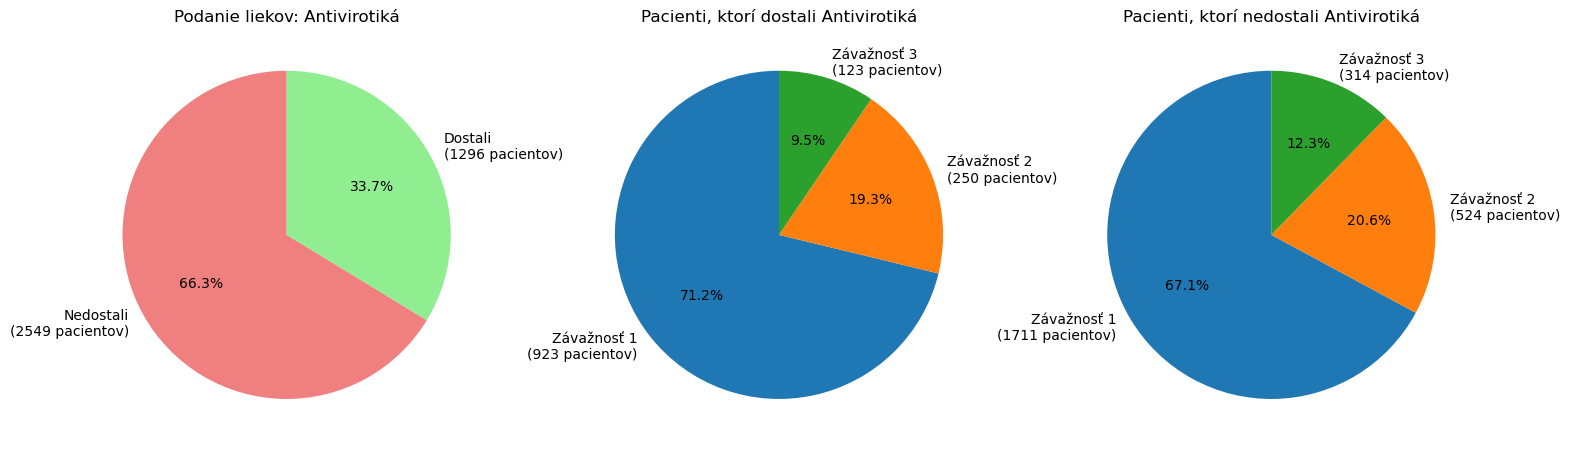

Chí-kvadrát: 8.832997027116292
p-hodnota: 0.012076443844381203
Cramerovo V: 0.0479298279526696


In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    'MD652 | FABIFLU TABLETS',
    'MD656 IV-BECT 6MG (ivermectin)',
    '5042D | VEKLURY',
    '9547D | PAXLOVID',
    'LAGEVRIO'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = 'Antivirotiká'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

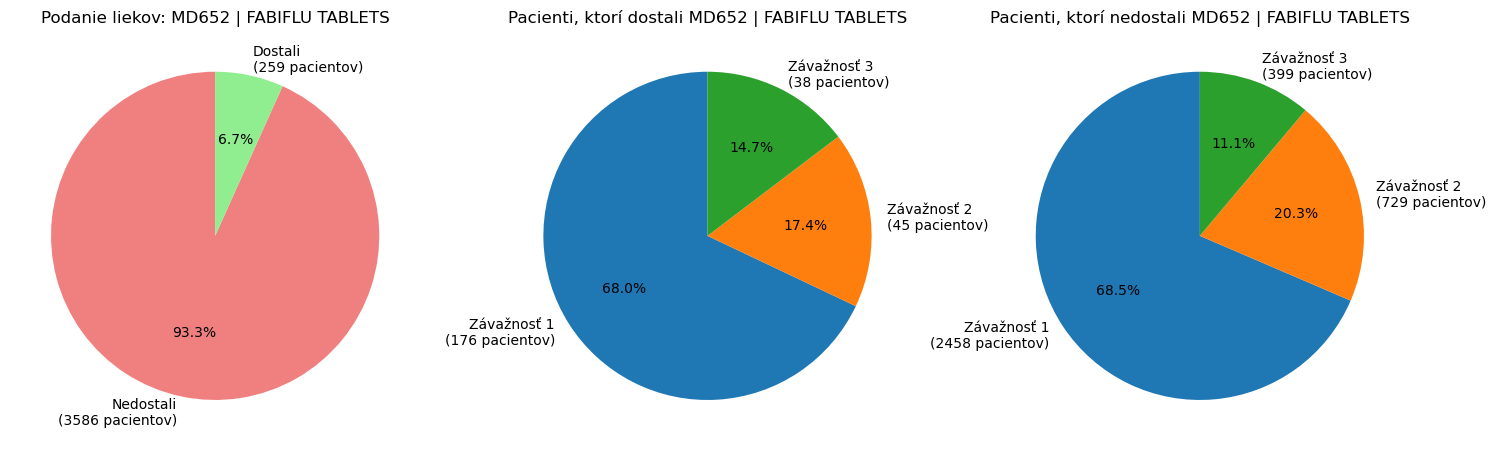

Chí-kvadrát: 3.7310293855175773
p-hodnota: 0.15481650644046788
Cramerovo V: 0.031150581822157478


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    'MD652 | FABIFLU TABLETS'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = 'MD652 | FABIFLU TABLETS'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

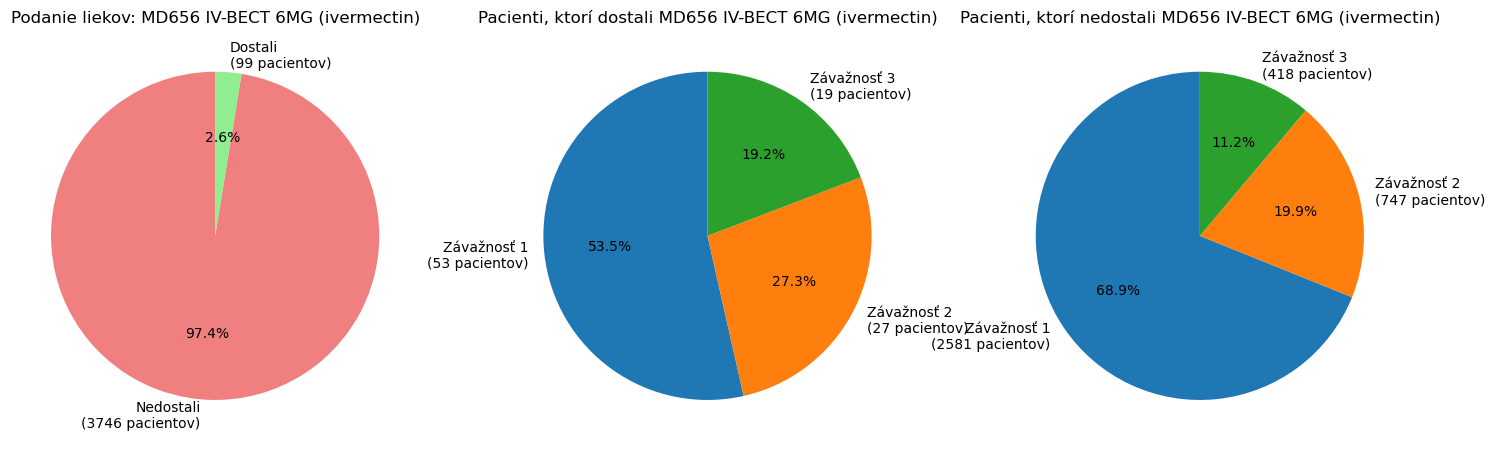

Chí-kvadrát: 11.375886163814775
p-hodnota: 0.0033865516695858033
Cramerovo V: 0.05439317960910391


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    'MD656 IV-BECT 6MG (ivermectin)'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = 'MD656 IV-BECT 6MG (ivermectin)'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

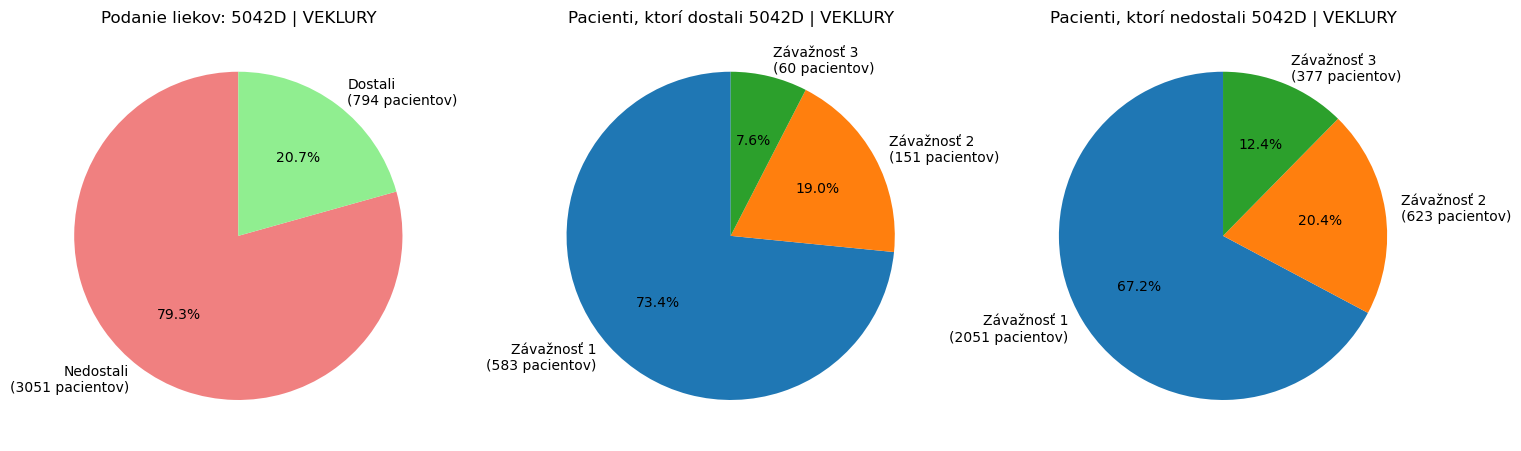

Chí-kvadrát: 16.924304662343335
p-hodnota: 0.0002113167572130798
Cramerovo V: 0.06634485439067979


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '5042D | VEKLURY'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '5042D | VEKLURY'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

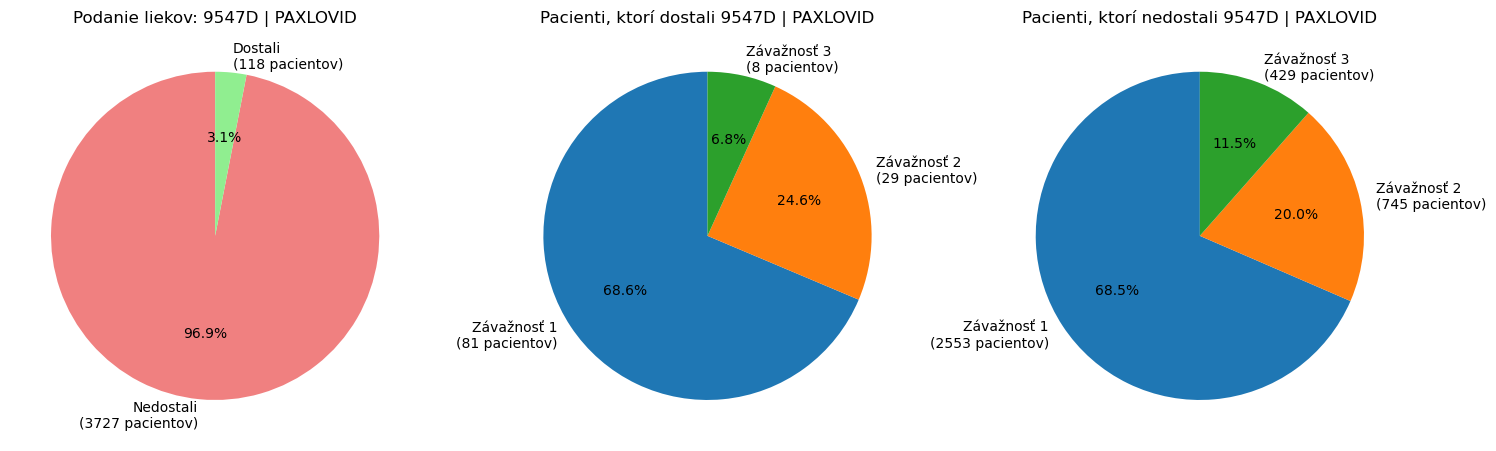

Chí-kvadrát: 3.4483165827429194
p-hodnota: 0.17832308470109626
Cramerovo V: 0.029947142783935756


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '9547D | PAXLOVID'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '9547D | PAXLOVID'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

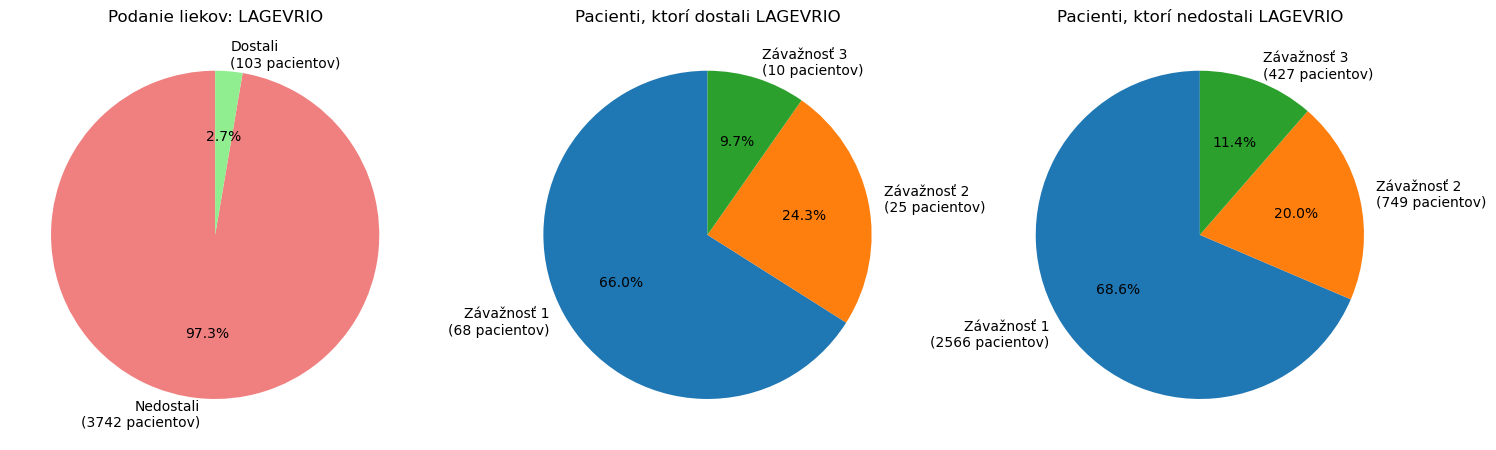

Chí-kvadrát: 1.2529009960335213
p-hodnota: 0.5344855956864931
Cramerovo V: 0.01805137154271352


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    'LAGEVRIO'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = 'LAGEVRIO'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

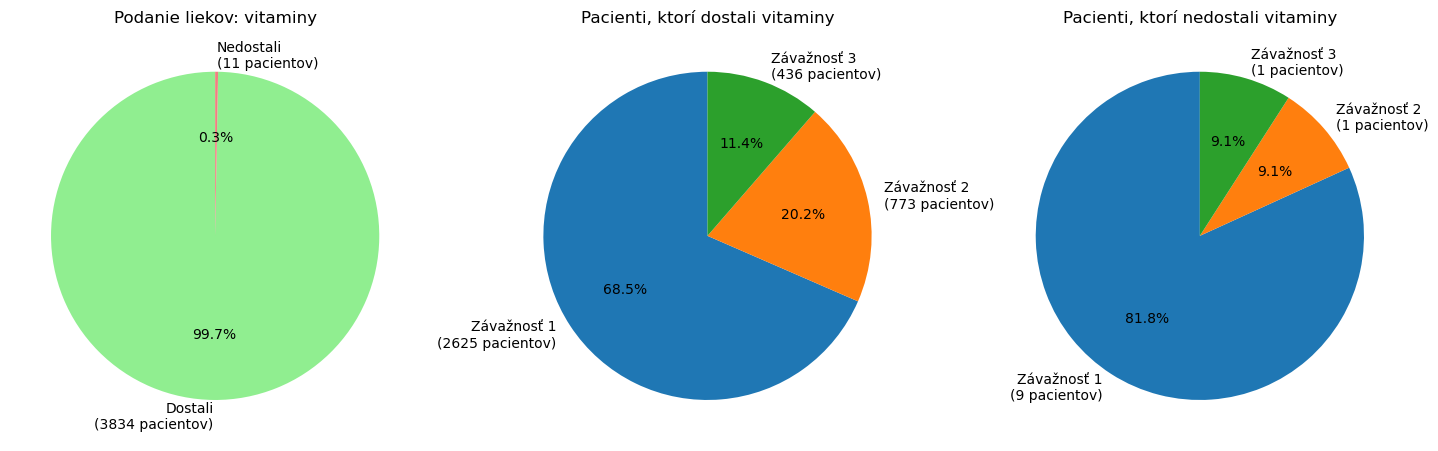

Chí-kvadrát: 1.003474996757207
p-hodnota: 0.6054777286726878
Cramerovo V: 0.01615493094058227


In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '00584 | PYRIDOXIN LÉČIVA INJ',
    '24836 | ACIDUM ASCORBICUM BBP',
    '24814 | CALCIFEROL BBP 7,5 MG/ML',
    '00498 | MAGNESIUM SULFURICUM BBP 100 MG/ML INJEKČNÝ ROZTOK',
    '00449 | EREVIT 300 MG/ML',
    '89145 | VITAMIN C-INJEKTOPAS',
    '92973 ALPHA D3'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = 'vitaminy'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightgreen', 'lightcoral']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

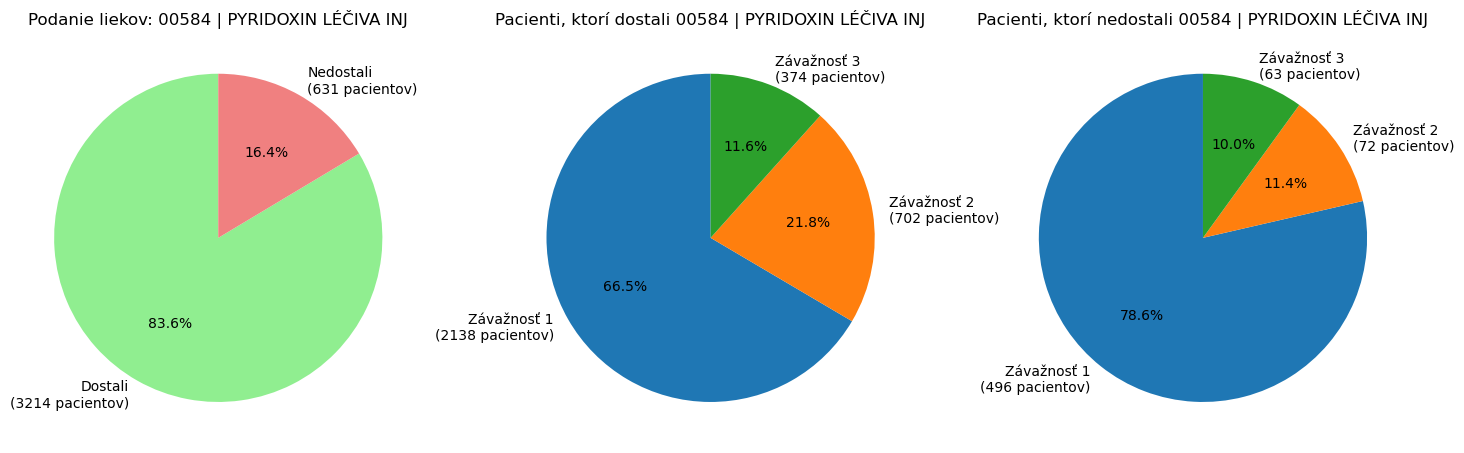

Chí-kvadrát: 41.02192177373289
p-hodnota: 1.2365249059582606e-09
Cramerovo V: 0.10329036901507291


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '00584 | PYRIDOXIN LÉČIVA INJ'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '00584 | PYRIDOXIN LÉČIVA INJ'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightgreen', 'lightcoral']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

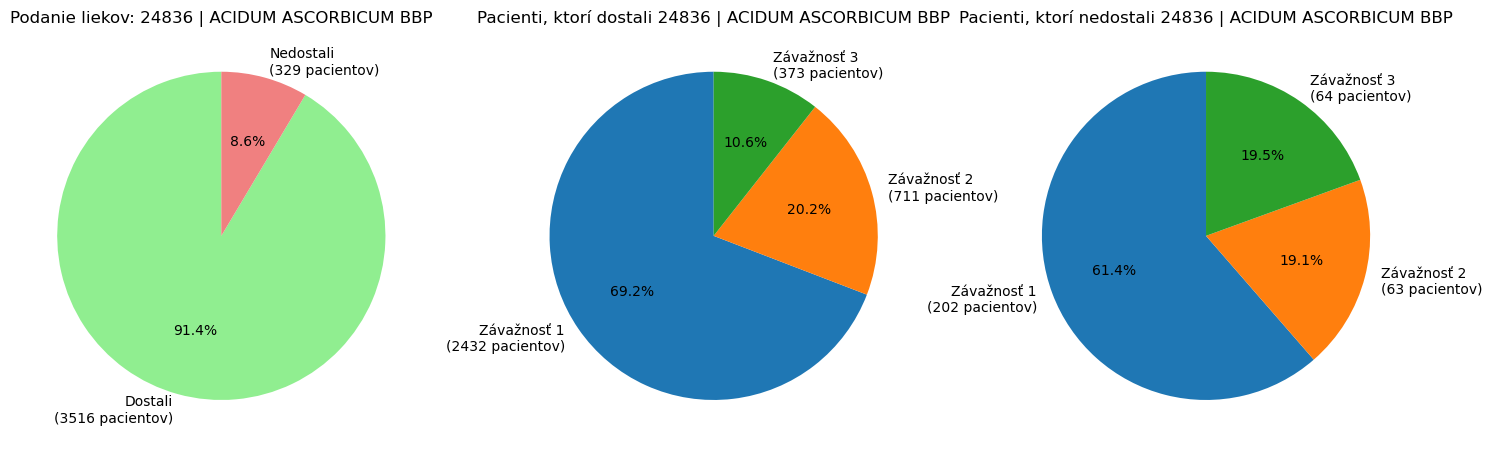

Chí-kvadrát: 23.529766074811306
p-hodnota: 7.772777153698297e-06
Cramerovo V: 0.07822771281308517


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '24836 | ACIDUM ASCORBICUM BBP'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '24836 | ACIDUM ASCORBICUM BBP'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightgreen', 'lightcoral']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

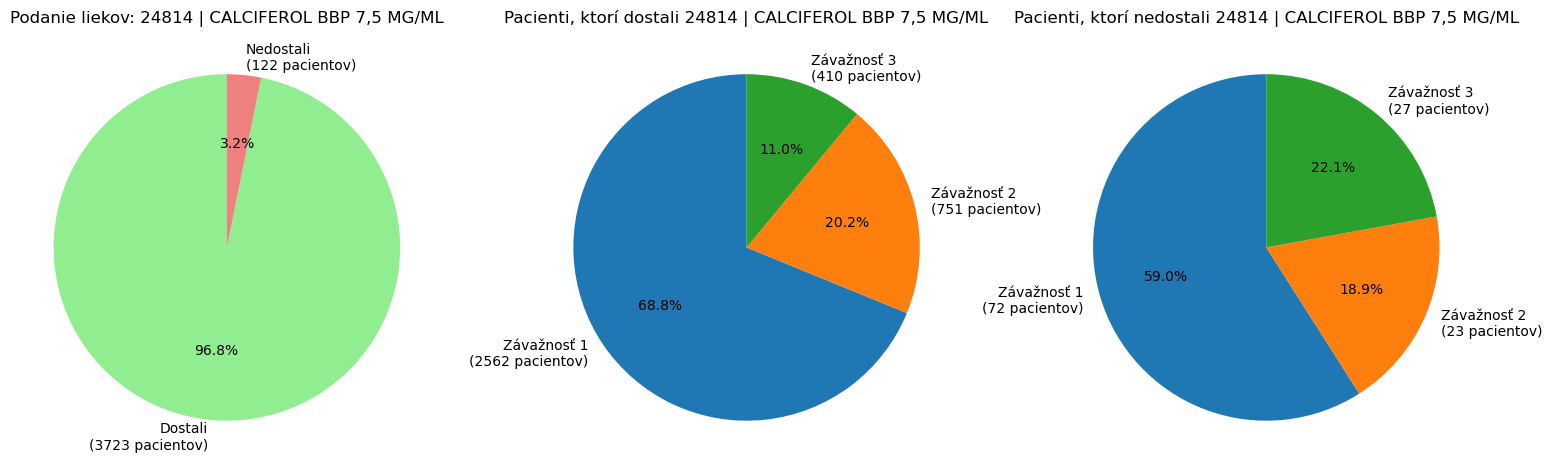

Chí-kvadrát: 14.606853104471258
p-hodnota: 0.0006732279676058858
Cramerovo V: 0.06163539148579823


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))


lieky = [
    '24814 | CALCIFEROL BBP 7,5 MG/ML'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '24814 | CALCIFEROL BBP 7,5 MG/ML'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightgreen', 'lightcoral']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

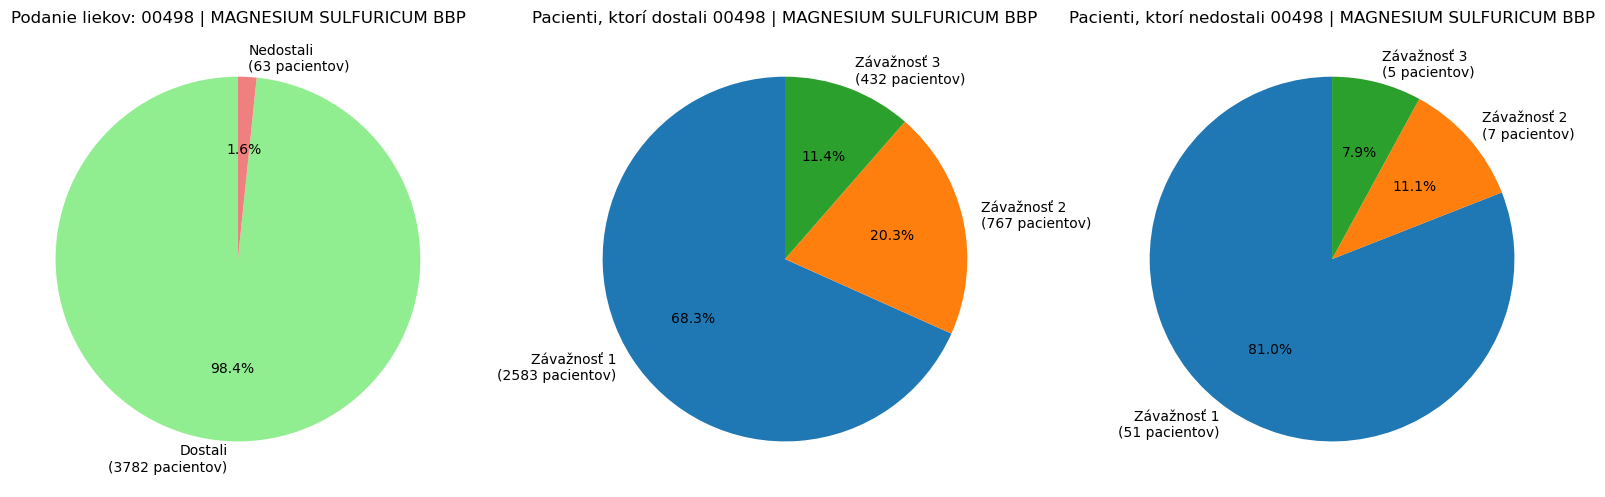

Chí-kvadrát: 4.699396128053375
p-hodnota: 0.0953979619439854
Cramerovo V: 0.03496011521992933


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))


lieky = [
    '00498 | MAGNESIUM SULFURICUM BBP 100 MG/ML INJEKČNÝ ROZTOK'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '00498 | MAGNESIUM SULFURICUM BBP'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightgreen', 'lightcoral']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

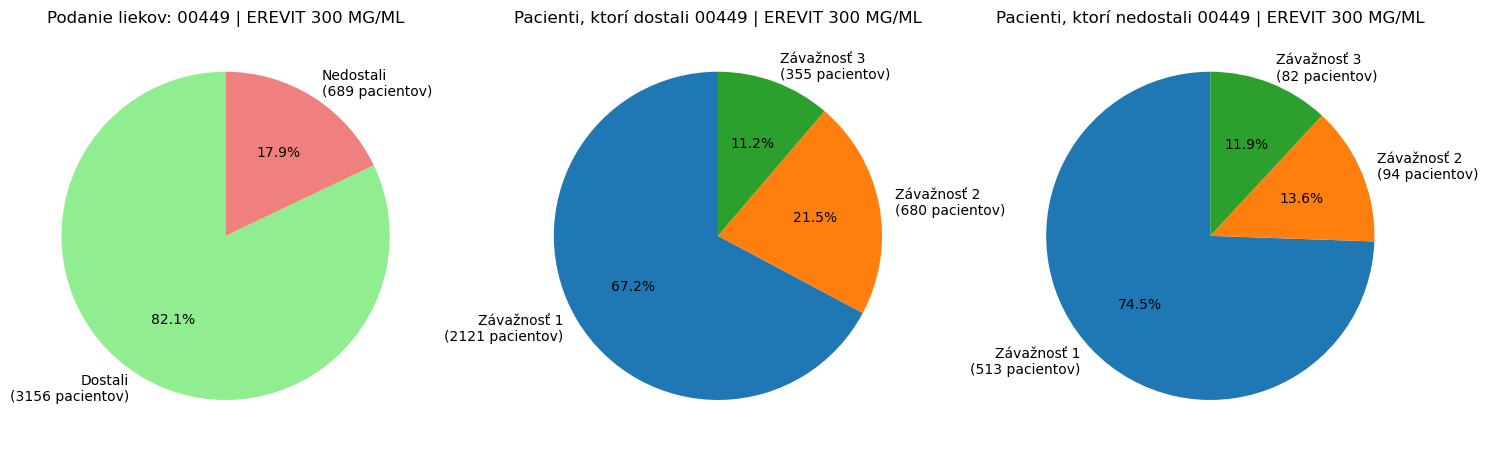

Chí-kvadrát: 22.100051296132875
p-hodnota: 1.5886741761454946e-05
Cramerovo V: 0.07581383553344359


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '00449 | EREVIT 300 MG/ML'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '00449 | EREVIT 300 MG/ML'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightgreen', 'lightcoral']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

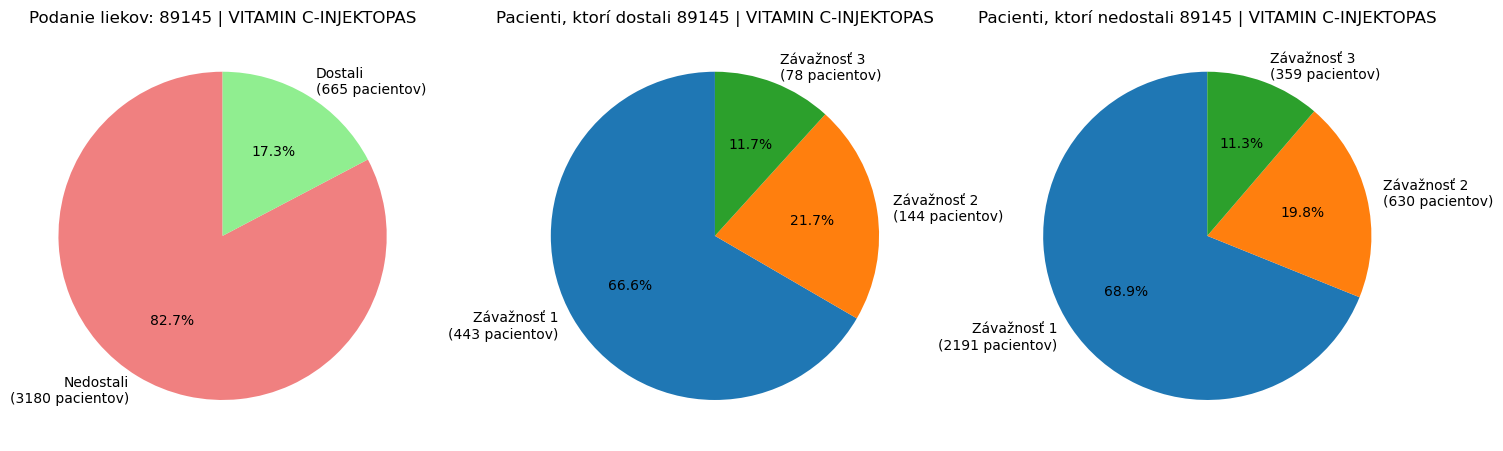

Chí-kvadrát: 1.439916503582275
p-hodnota: 0.48677257741900715
Cramerovo V: 0.01935176059491302


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '89145 | VITAMIN C-INJEKTOPAS'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '89145 | VITAMIN C-INJEKTOPAS'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

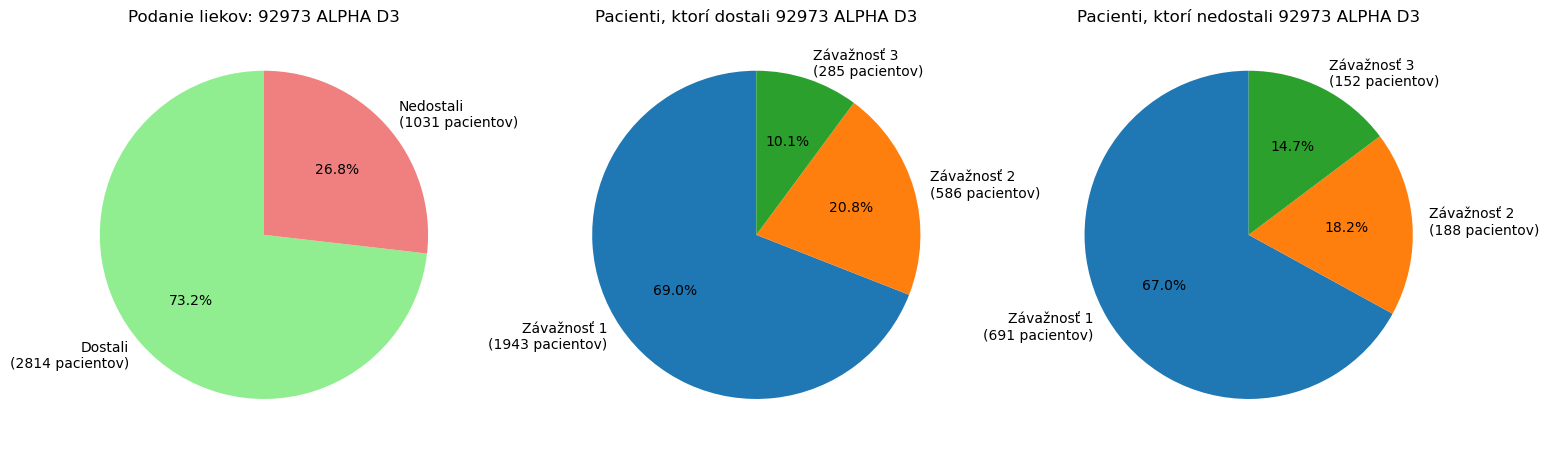

Chí-kvadrát: 17.105781425757165
p-hodnota: 0.00019298642412039085
Cramerovo V: 0.06669960885974877


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '92973 ALPHA D3'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '92973 ALPHA D3'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightgreen', 'lightcoral']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

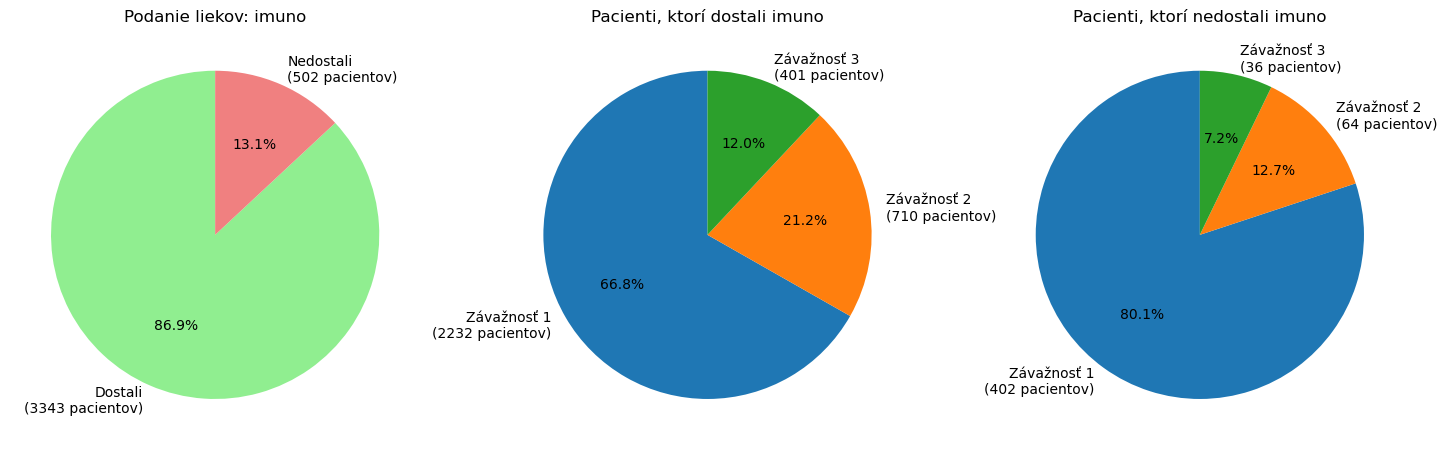

Chí-kvadrát: 35.855107141760605
p-hodnota: 1.637428744992456e-08
Cramerovo V: 0.09656668884494331


In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '02963 | PREDNISON 20 LÉČIVA',
    '84090 | DEXAMED 6',
    '1275C | DEXAMETAZÓN KRKA',
    'MD661 BIODEXONE-DEXAMETHASONE',
    '2410B HYDROCORTISONE',
    '3242C | OLUMIANT 4 MG',
    'Anakinra',
    'RoActemra'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = 'imuno'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightgreen', 'lightcoral']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

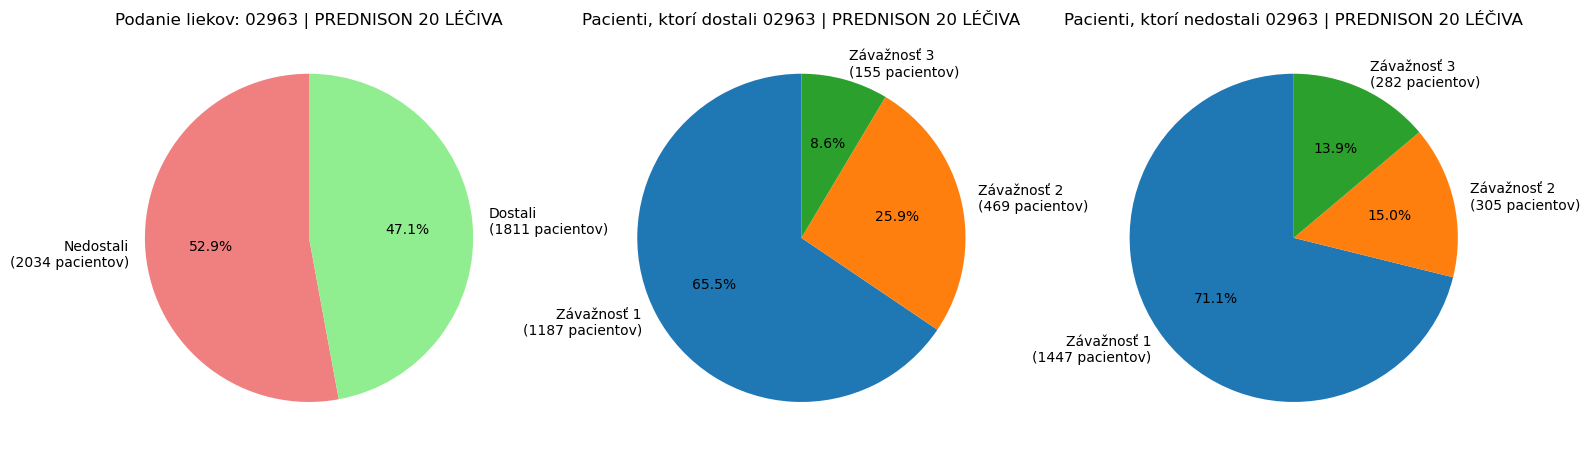

Chí-kvadrát: 84.67360602674435
p-hodnota: 4.105443407501211e-19
Cramerovo V: 0.1483972509522349


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '02963 | PREDNISON 20 LÉČIVA'
    #IDENTICKE AKO PRE 00269 | PREDNISON 5 LÉČIVA
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '02963 | PREDNISON 20 LÉČIVA'
    #IDENTICKE AKO PRE 00269 | PREDNISON 5 LÉČIVA

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

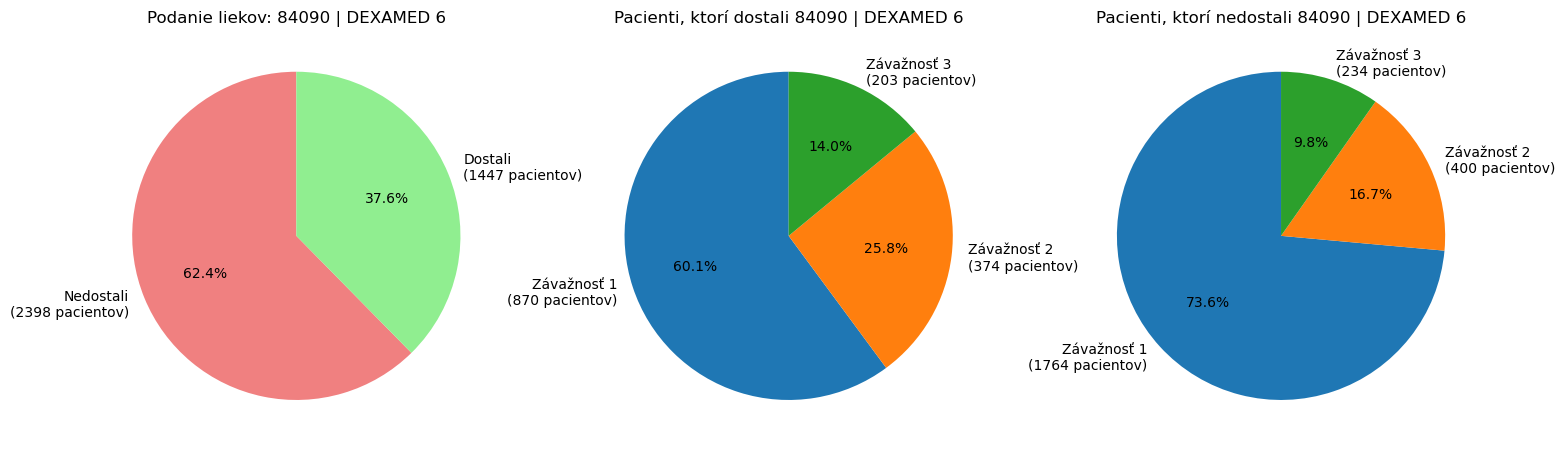

Chí-kvadrát: 75.93333039454426
p-hodnota: 3.24553882334219e-17
Cramerovo V: 0.14052967828798807


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '84090 | DEXAMED 6'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '84090 | DEXAMED 6'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

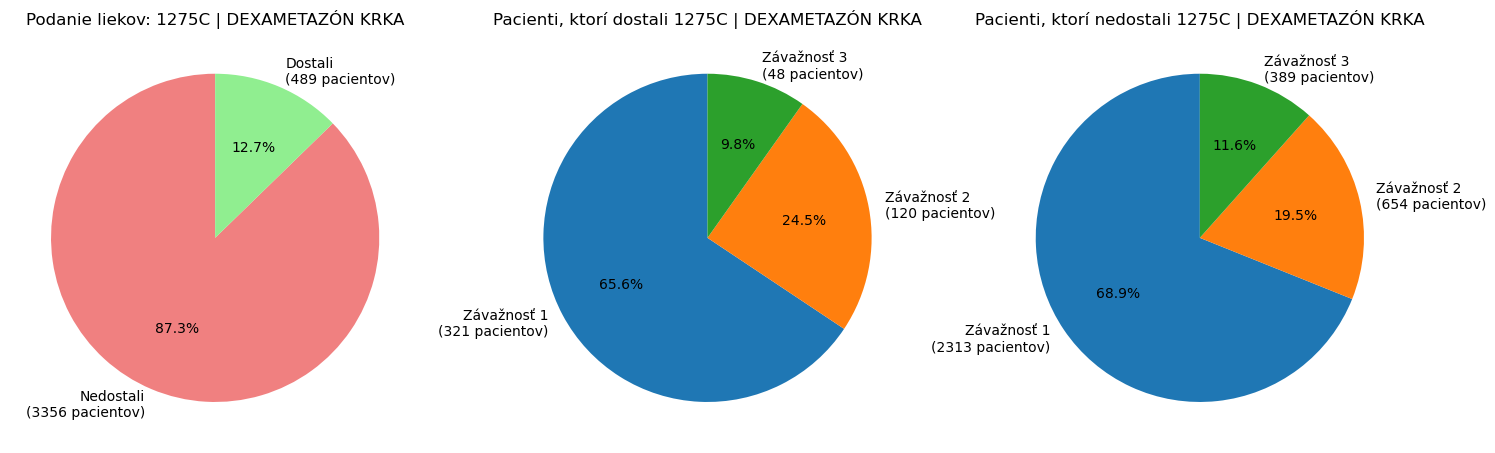

Chí-kvadrát: 7.264929703776796
p-hodnota: 0.026450906425011397
Cramerovo V: 0.04346778758516739


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '1275C | DEXAMETAZÓN KRKA'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '1275C | DEXAMETAZÓN KRKA'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

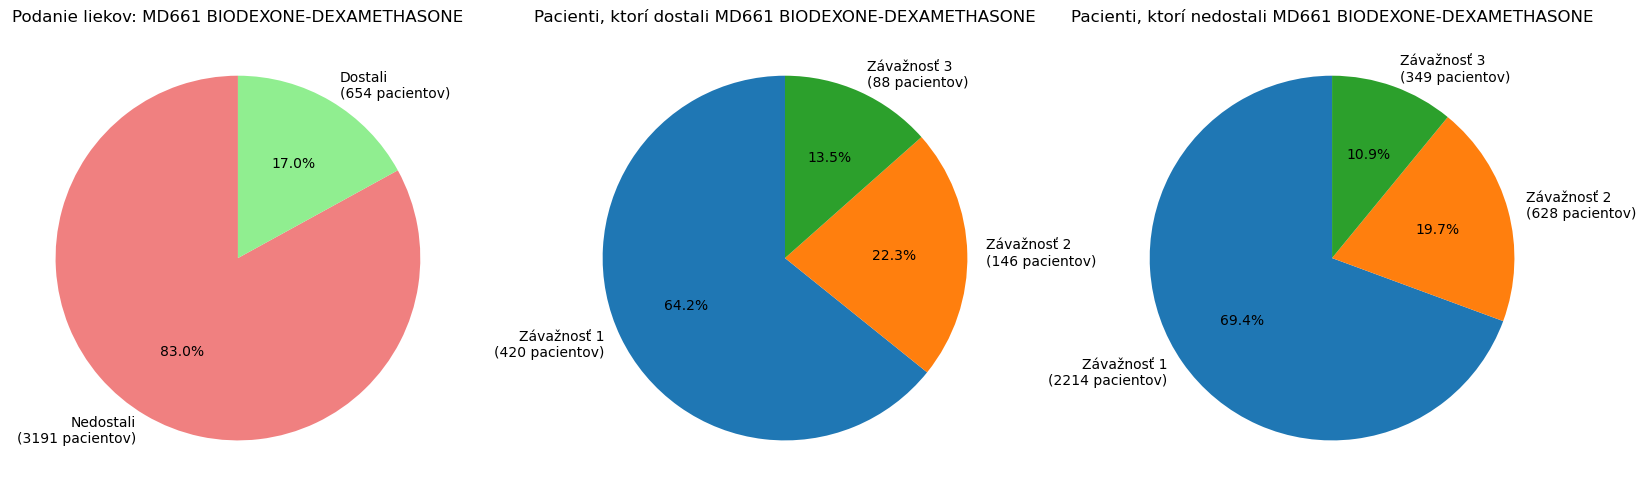

Chí-kvadrát: 7.025576455410677
p-hodnota: 0.029813671136356863
Cramerovo V: 0.04274573707187796


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))


lieky = [
    'MD661 BIODEXONE-DEXAMETHASONE'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = 'MD661 BIODEXONE-DEXAMETHASONE'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

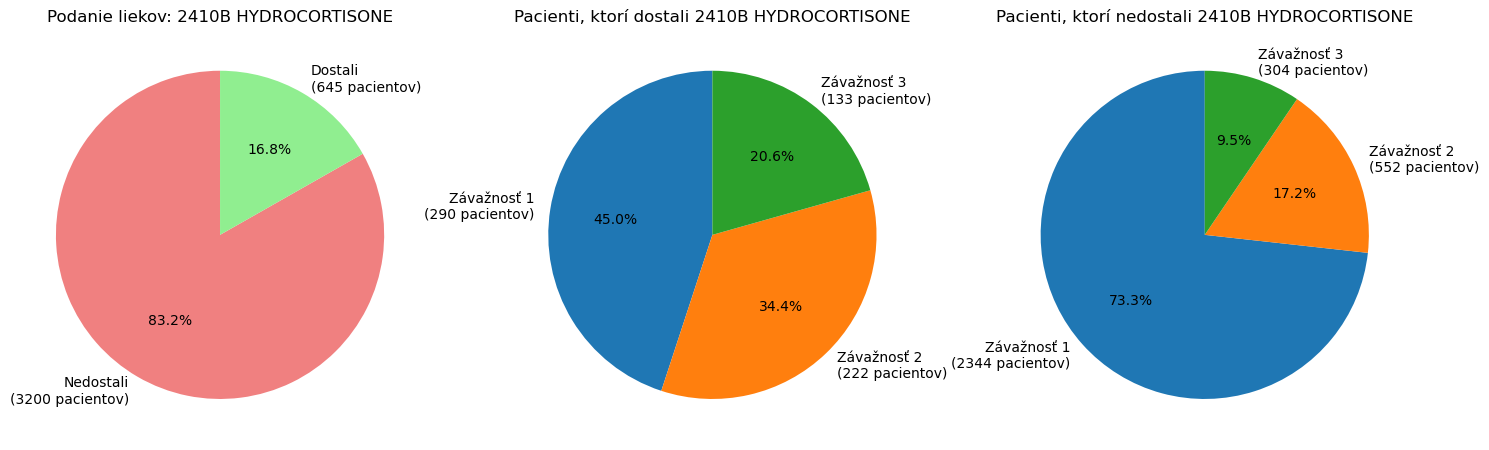

Chí-kvadrát: 199.71574234581726
p-hodnota: 4.288225104729443e-44
Cramerovo V: 0.22790716424142146


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '2410B HYDROCORTISONE'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '2410B HYDROCORTISONE'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

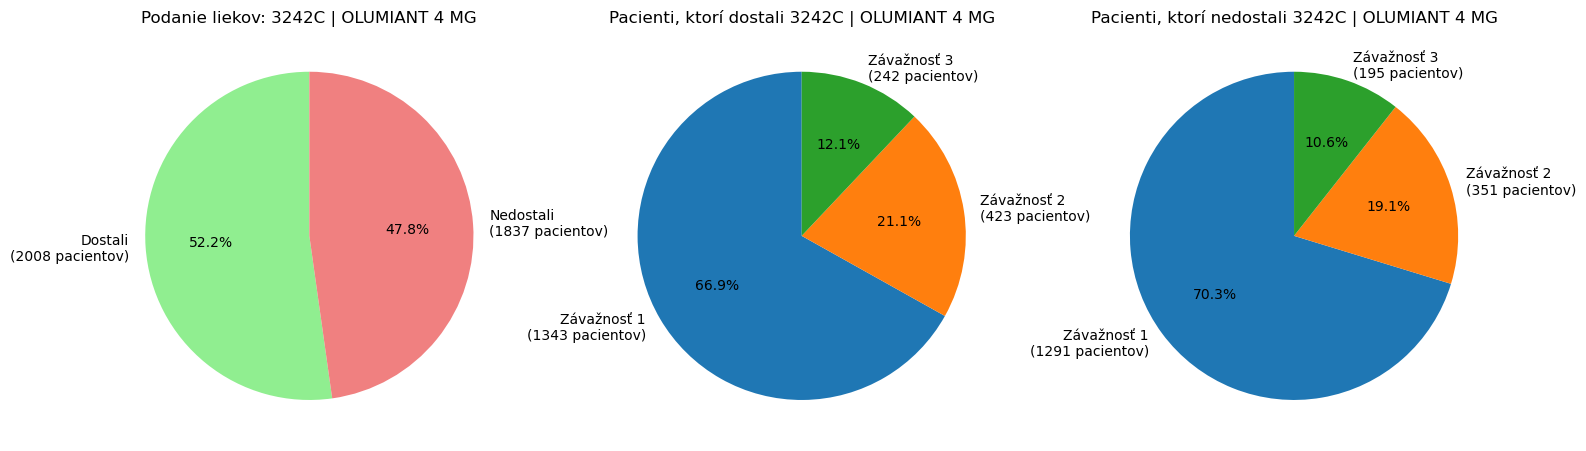

Chí-kvadrát: 5.184482670106744
p-hodnota: 0.07485208333376774
Cramerovo V: 0.036720158022935066


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '3242C | OLUMIANT 4 MG'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '3242C | OLUMIANT 4 MG'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightgreen', 'lightcoral']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

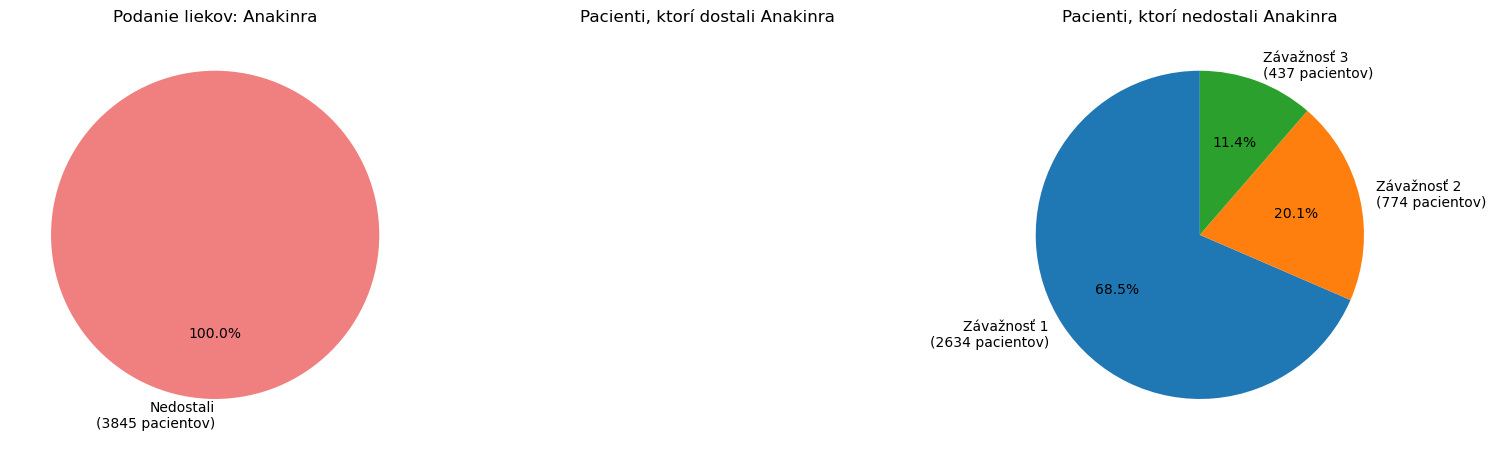

Chí-kvadrát: 0.0
p-hodnota: 1.0
Cramerovo V: nan


c:\ProgramData\anaconda3\Lib\site-packages\scipy\stats\contingency.py:459: RuntimeWarning: invalid value encountered in scalar divide
  value = phi2 / min(n_cols - 1, n_rows - 1)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    'Anakinra'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = 'Anakinra'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

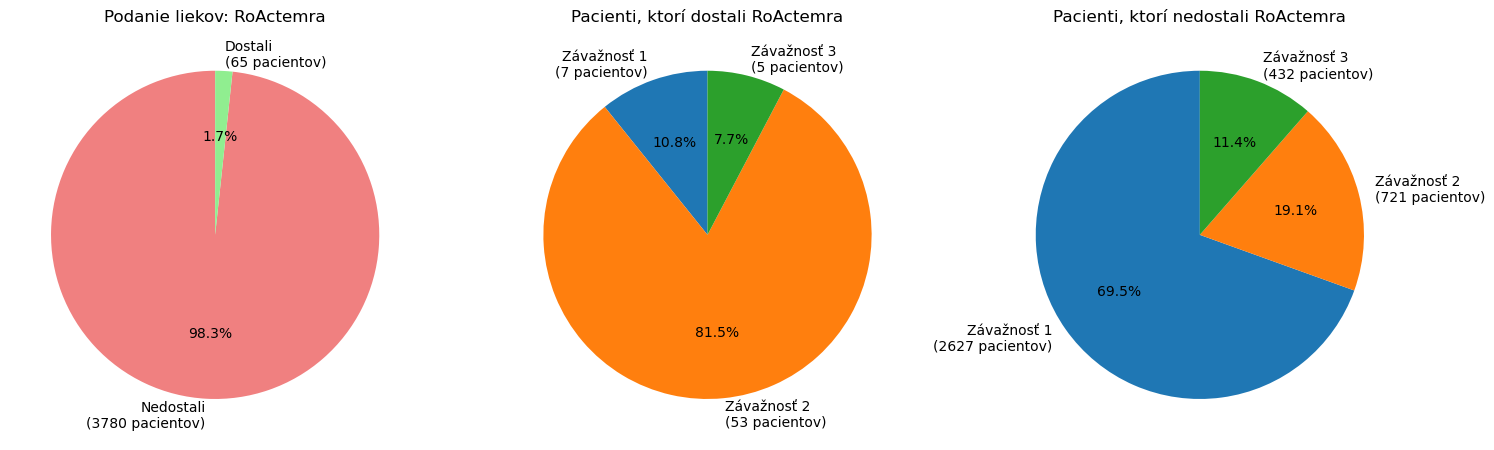

Chí-kvadrát: 156.81659255990525
p-hodnota: 8.865629750415027e-35
Cramerovo V: 0.20195184928691415


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    'RoActemra'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = 'RoActemra'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

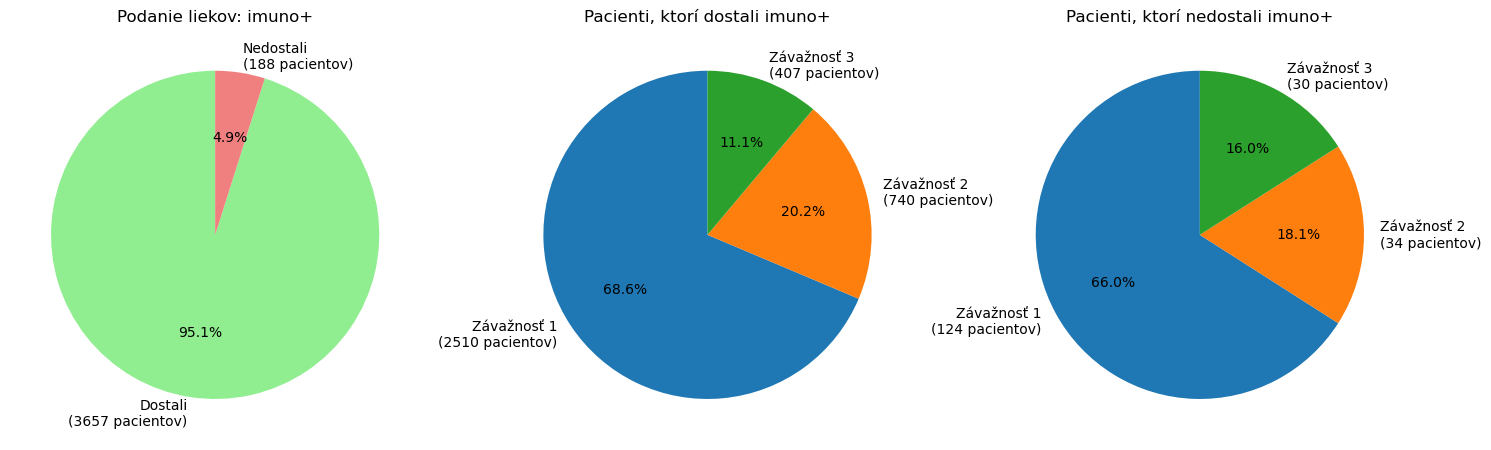

Chí-kvadrát: 4.265193043645459
p-hodnota: 0.11852913047516928
Cramerovo V: 0.03330590002147805


In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '34045 | POLYOXIDONIUM 6 MG',
    '87299 | IMUNOR',
    '56930 IMMODIN',
    'Isoprinosine, ',
    '00449 | EREVIT 300 MG/ML',
    '89145 | VITAMIN C-INJEKTOPAS',
    '3879d INOMED'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = 'imuno+'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightgreen', 'lightcoral']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

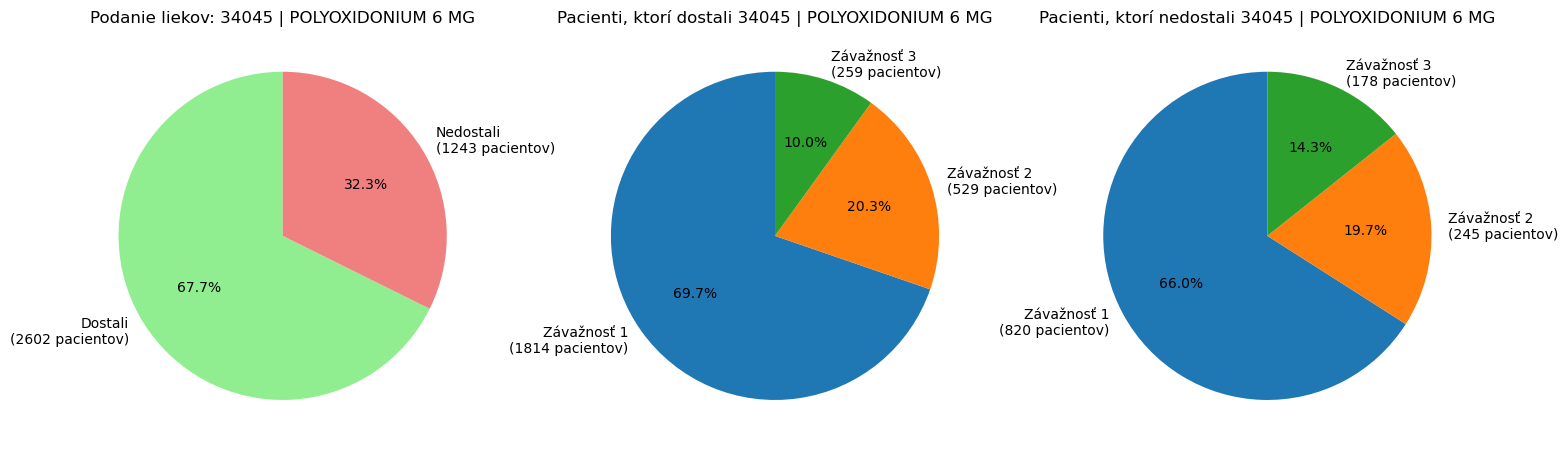

Chí-kvadrát: 15.993890887353778
p-hodnota: 0.0003364888839742846
Cramerovo V: 0.06449542253966985


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '34045 | POLYOXIDONIUM 6 MG'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '34045 | POLYOXIDONIUM 6 MG'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightgreen', 'lightcoral']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

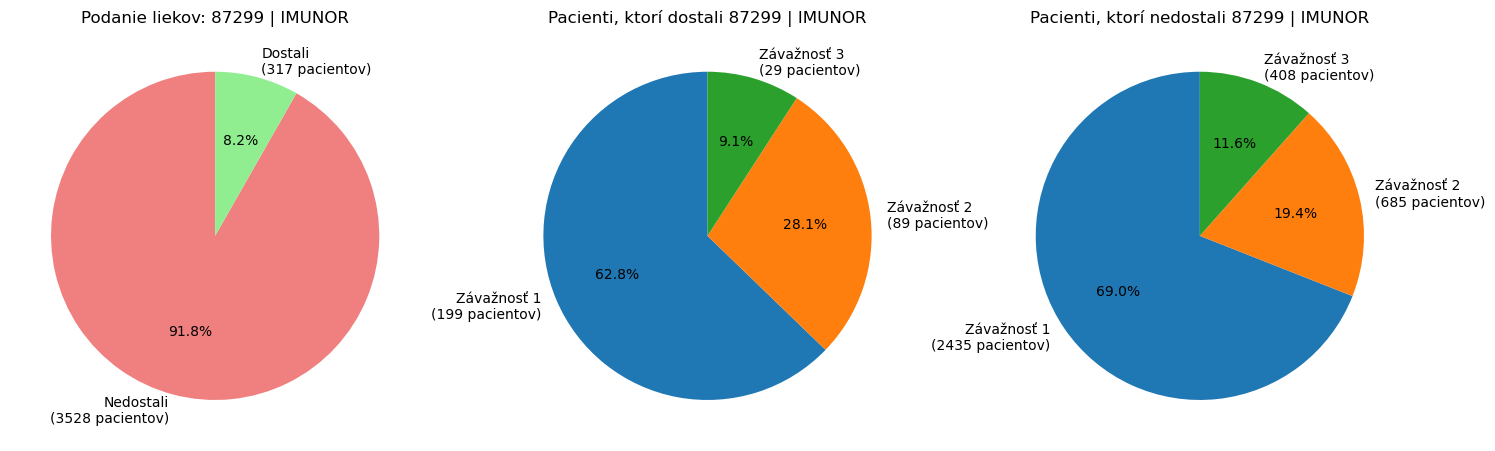

Chí-kvadrát: 13.9846206042479
p-hodnota: 0.0009189210920602058
Cramerovo V: 0.060308311905158715


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '87299 | IMUNOR'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '87299 | IMUNOR'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

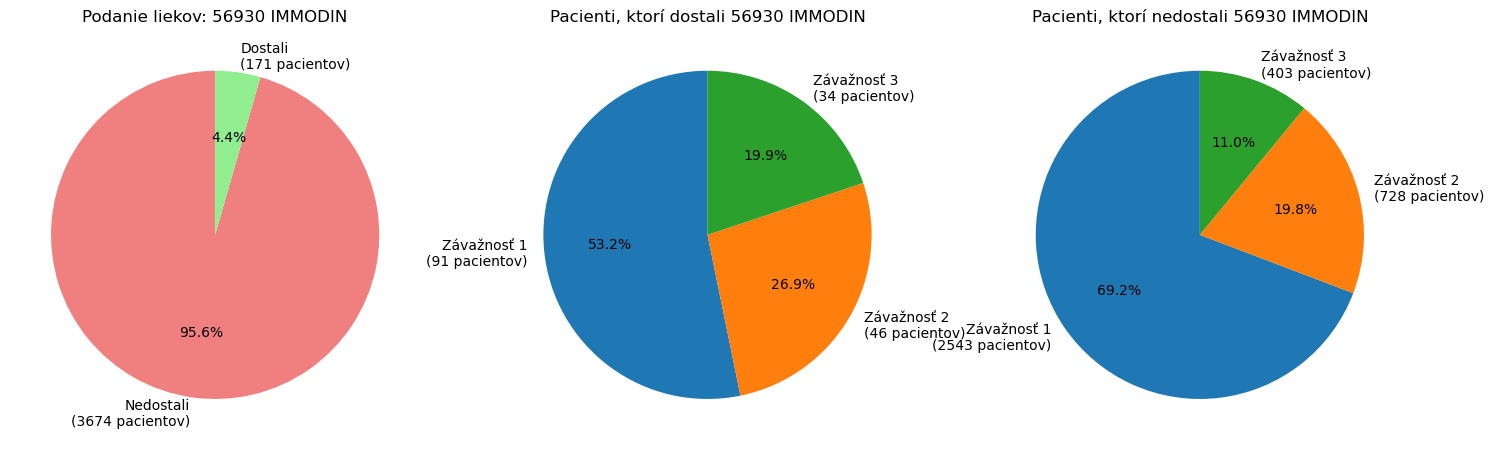

Chí-kvadrát: 21.604781107606694
p-hodnota: 2.0350795543291474e-05
Cramerovo V: 0.07495951418337583


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '56930 IMMODIN'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '56930 IMMODIN'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

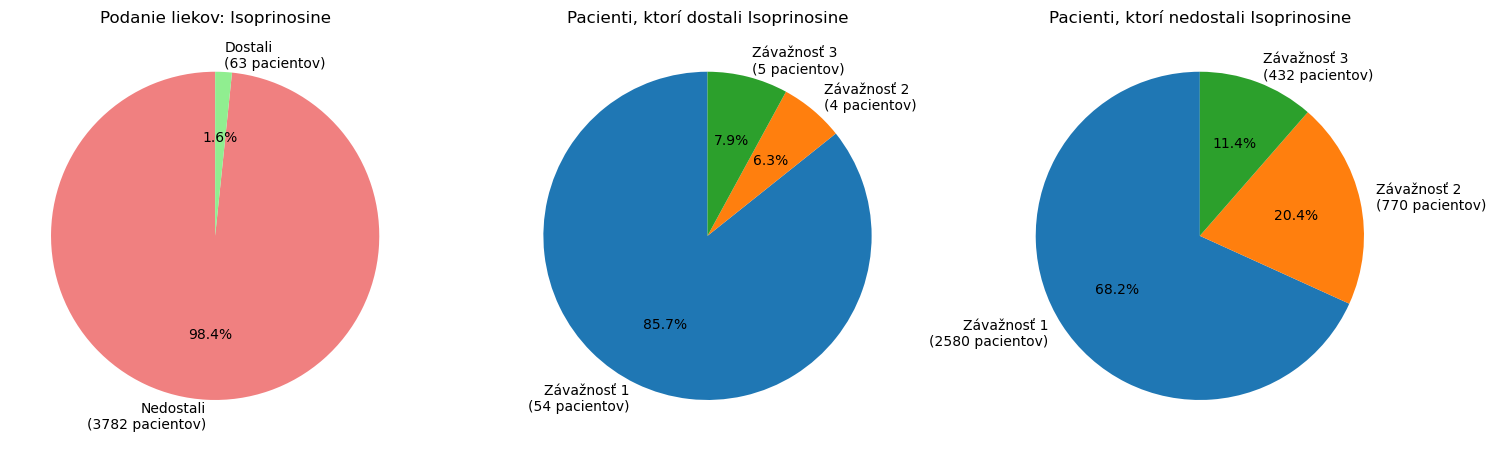

Chí-kvadrát: 9.47428875099258
p-hodnota: 0.008763636141633455
Cramerovo V: 0.049639241448127855


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    'Isoprinosine, '
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = 'Isoprinosine'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

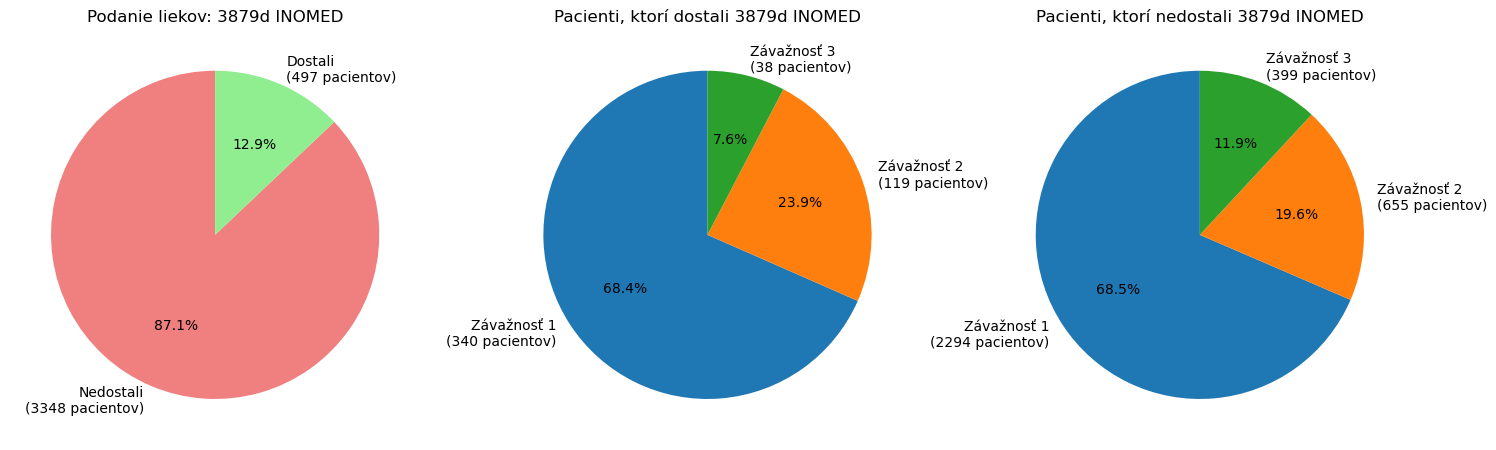

Chí-kvadrát: 11.072535645147125
p-hodnota: 0.003941208713775789
Cramerovo V: 0.05366305232367668


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '3879d INOMED'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '3879d INOMED'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

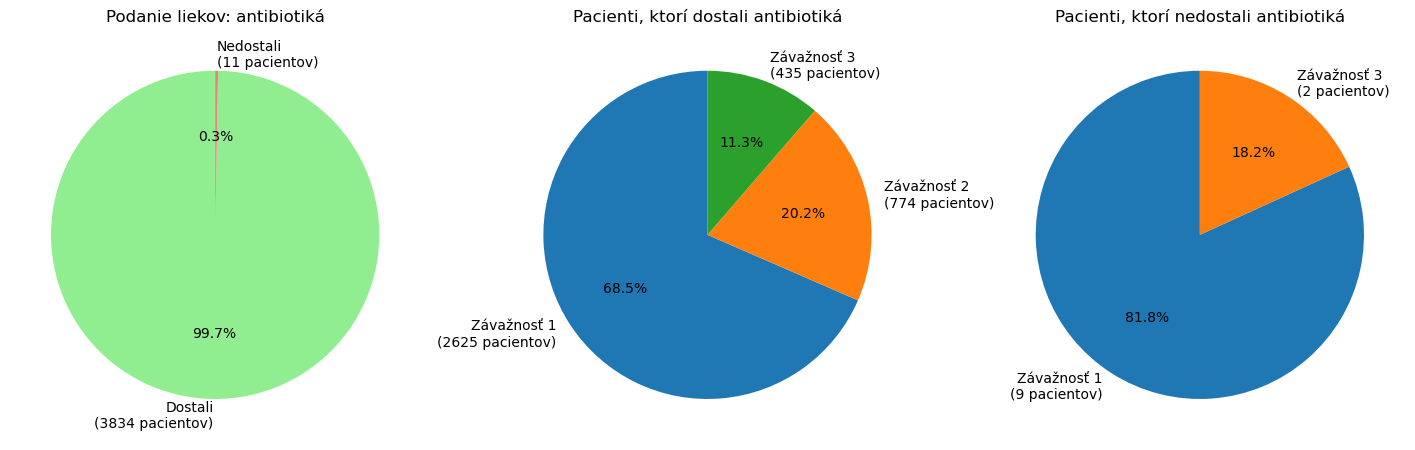

Chí-kvadrát: 2.9570804166333353
p-hodnota: 0.22797023465321317
Cramerovo V: 0.027732140736221777


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '35715 Azithromycin',
    '45954 Ceftriaxon',
    '0471B MOLOXIN',
    '9819A MOXIFLOXACIN',
    '58730 CIPROFLOXACIN KABI 200',
    '58746 CIPROFLOXACINKABI 400'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = 'antibiotiká'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightgreen', 'lightcoral']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

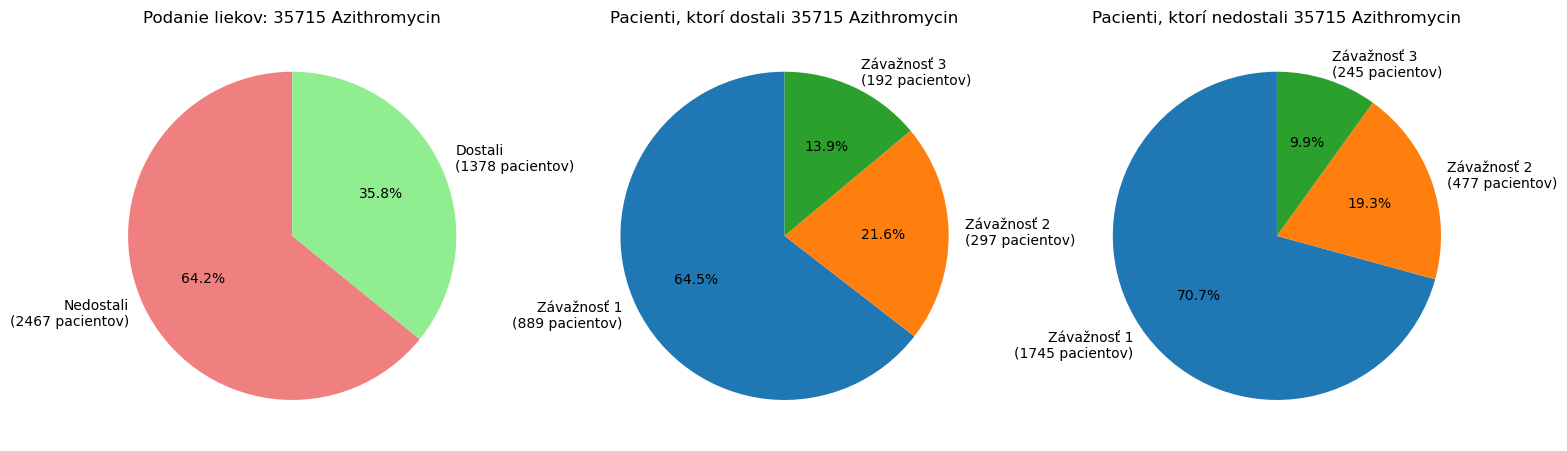

Chí-kvadrát: 19.613465319166004
p-hodnota: 5.507951664872749e-05
Cramerovo V: 0.07142150441128269


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '35715 Azithromycin'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '35715 Azithromycin'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

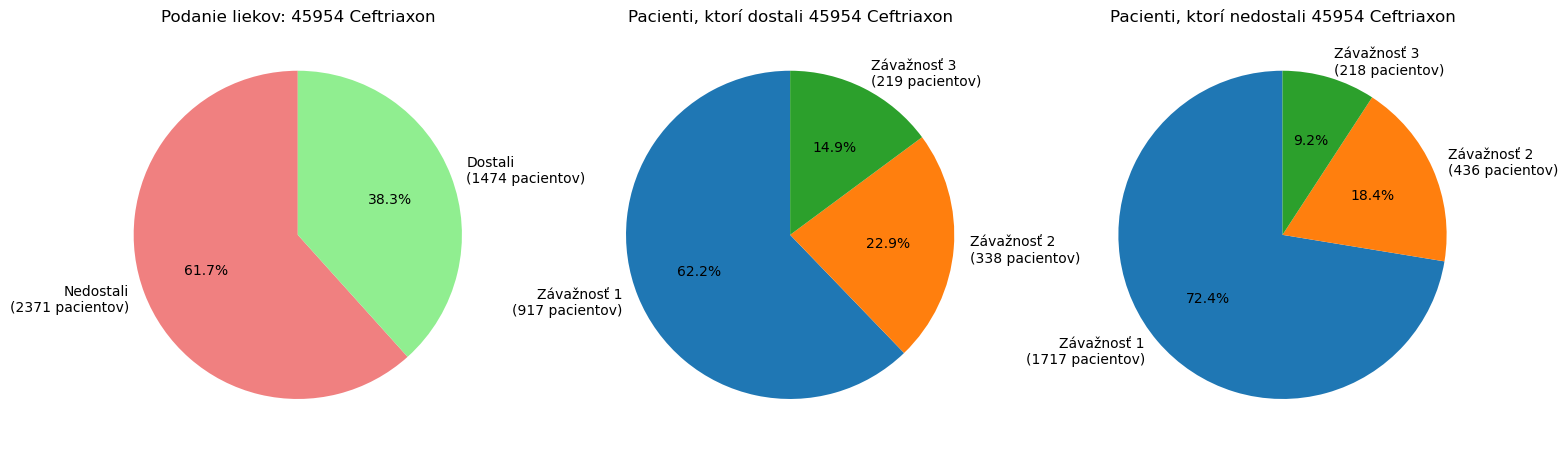

Chí-kvadrát: 48.780754819224285
p-hodnota: 2.555016325650559e-11
Cramerovo V: 0.11263570612237675


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '45954 Ceftriaxon'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '45954 Ceftriaxon'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

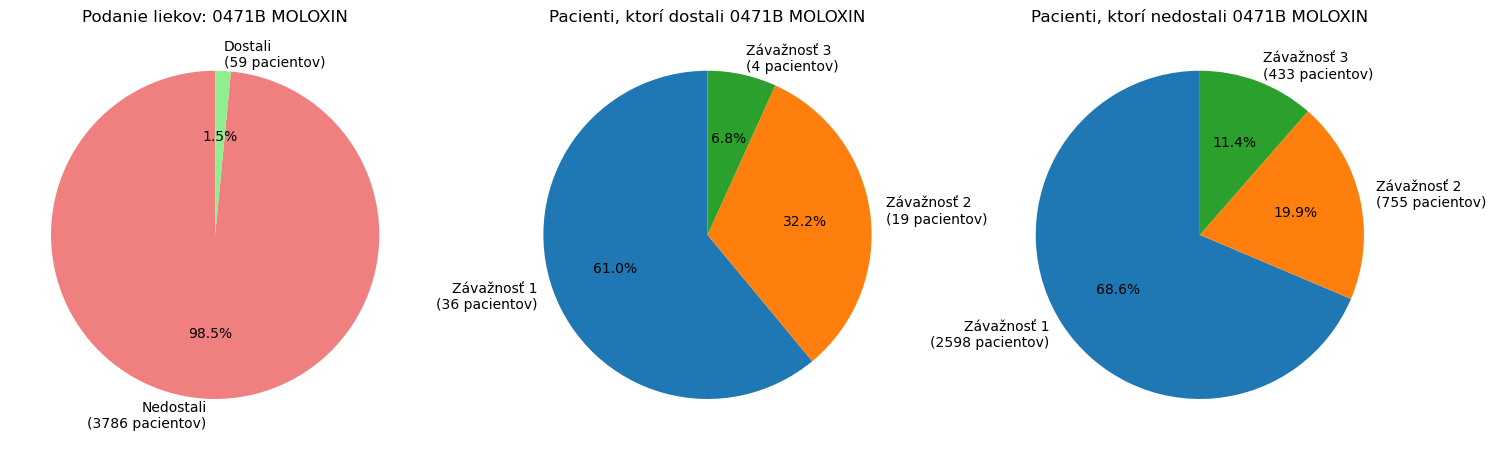

Chí-kvadrát: 5.937944691338887
p-hodnota: 0.05135605950026699
Cramerovo V: 0.03929795056263924


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '0471B MOLOXIN'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '0471B MOLOXIN'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

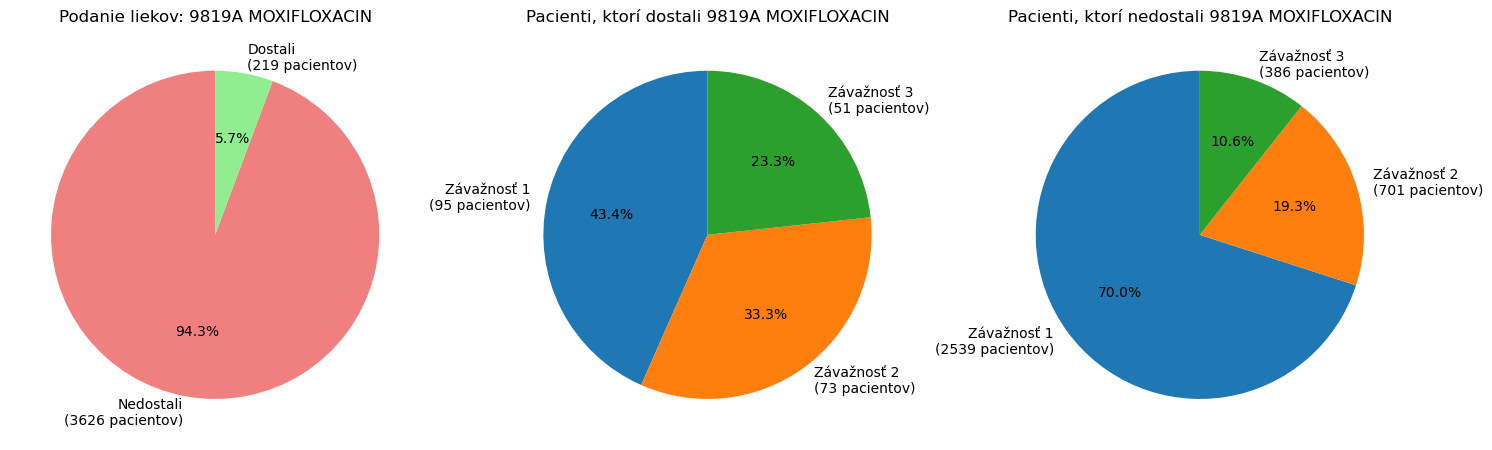

Chí-kvadrát: 70.55471258970248
p-hodnota: 4.777919463426857e-16
Cramerovo V: 0.13546117595968357


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '9819A MOXIFLOXACIN'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '9819A MOXIFLOXACIN'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

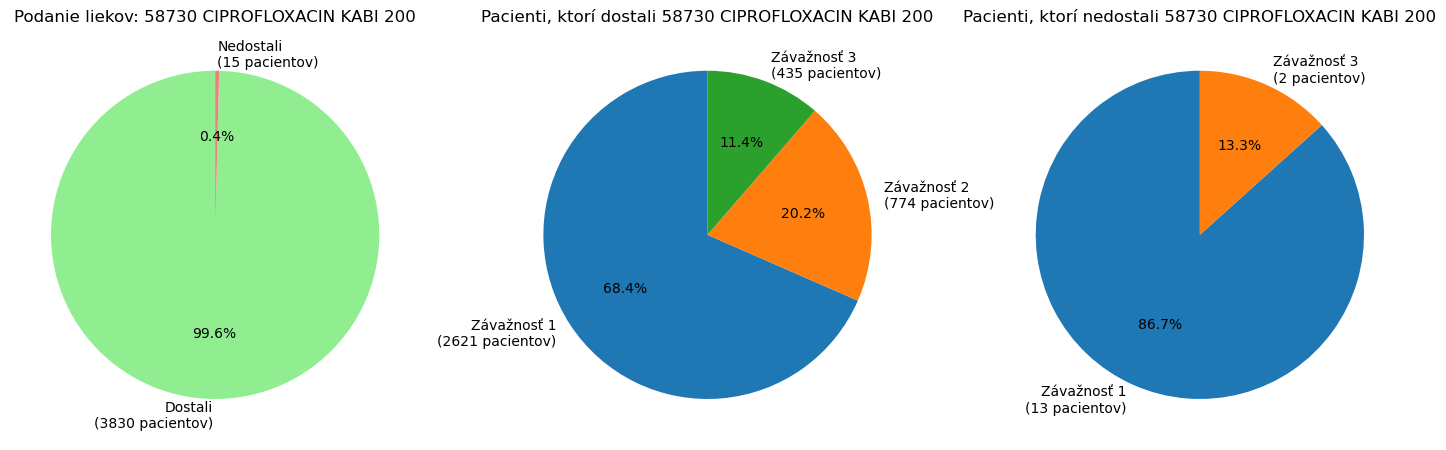

Chí-kvadrát: 3.807751017850803
p-hodnota: 0.14899008648238624
Cramerovo V: 0.031469228753636676


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '58730 CIPROFLOXACIN KABI 200'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '58730 CIPROFLOXACIN KABI 200'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightgreen', 'lightcoral']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

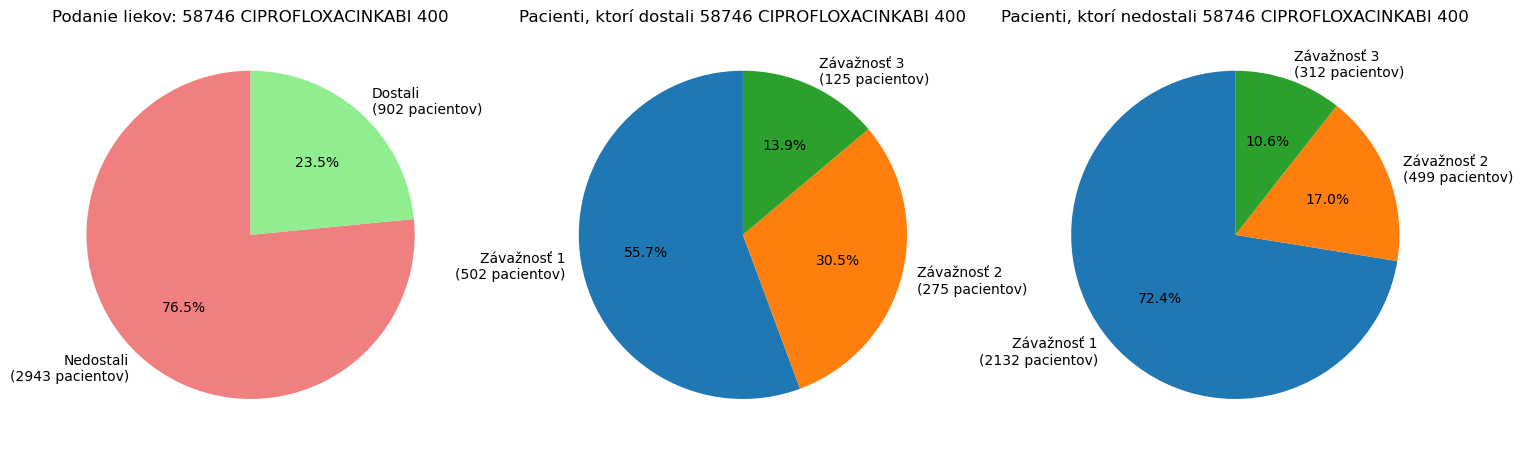

Chí-kvadrát: 97.65576290279756
p-hodnota: 6.227597313643396e-22
Cramerovo V: 0.15936786937794076


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '58746 CIPROFLOXACINKABI 400'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '58746 CIPROFLOXACINKABI 400'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

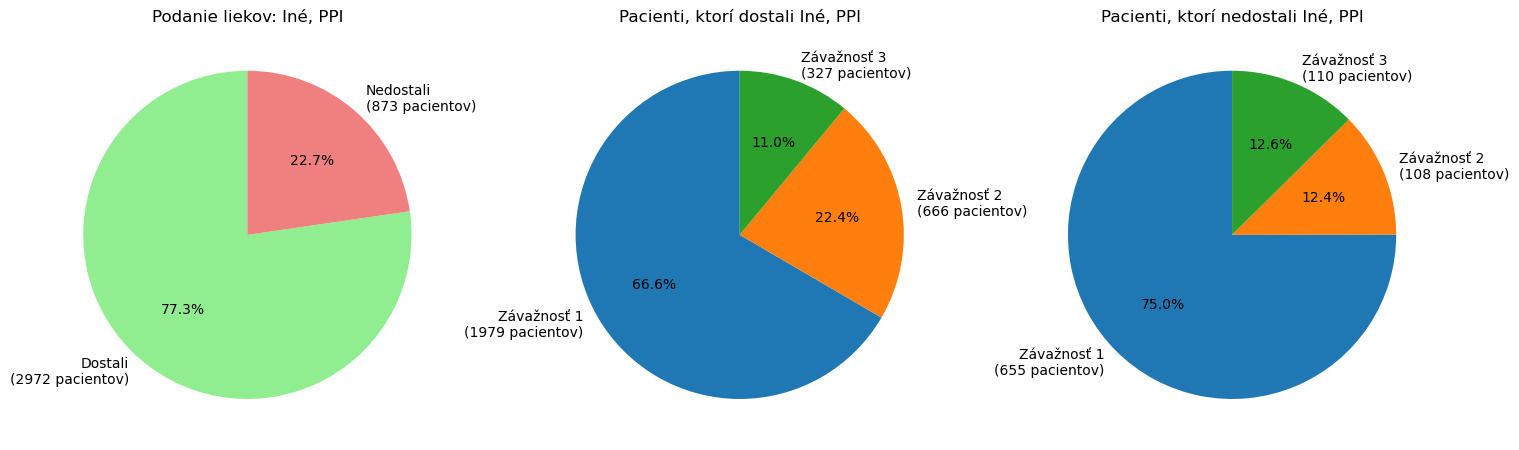

Chí-kvadrát: 42.309498745881555
p-hodnota: 6.495447565586872e-10
Cramerovo V: 0.10489885988498997


In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '05044 OZZION',
    '4147C OMEMYL',
    '89662 NOLPAZA',
    '39397 PANTOPRAZOL',
    '62916 SMECTA',
    '30639 REASEC',
    '84370 LAGOSA',
    '93105 DEGAN '
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = 'Iné, PPI'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightgreen', 'lightcoral']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

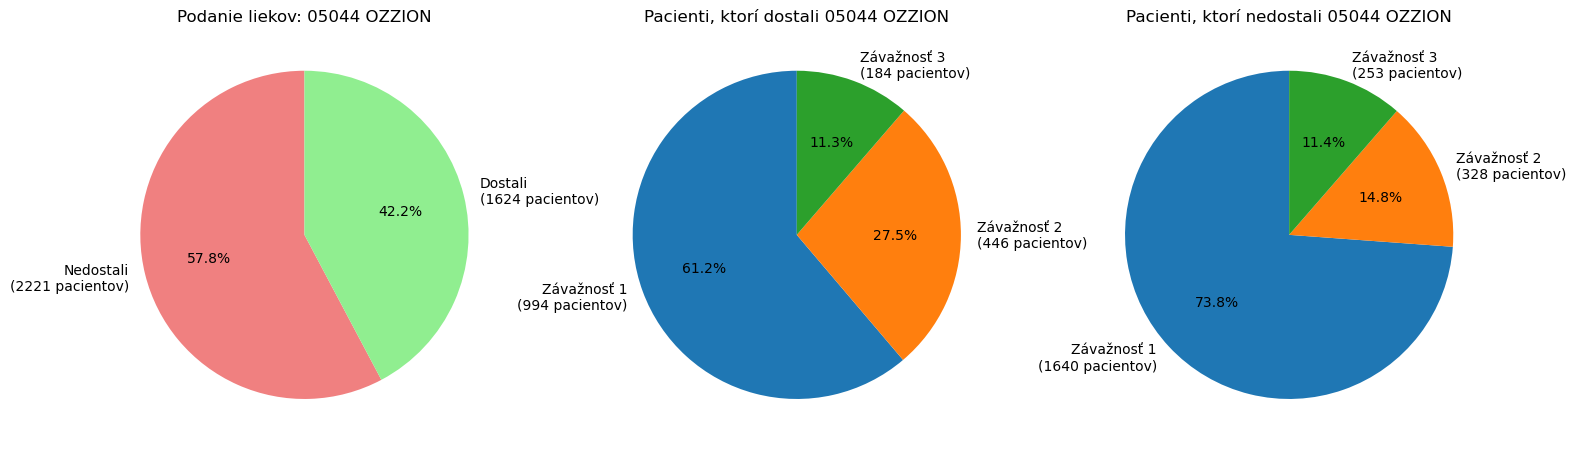

Chí-kvadrát: 96.96210755861917
p-hodnota: 8.809390603523113e-22
Cramerovo V: 0.1588008604486284


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '05044 OZZION'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '05044 OZZION'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

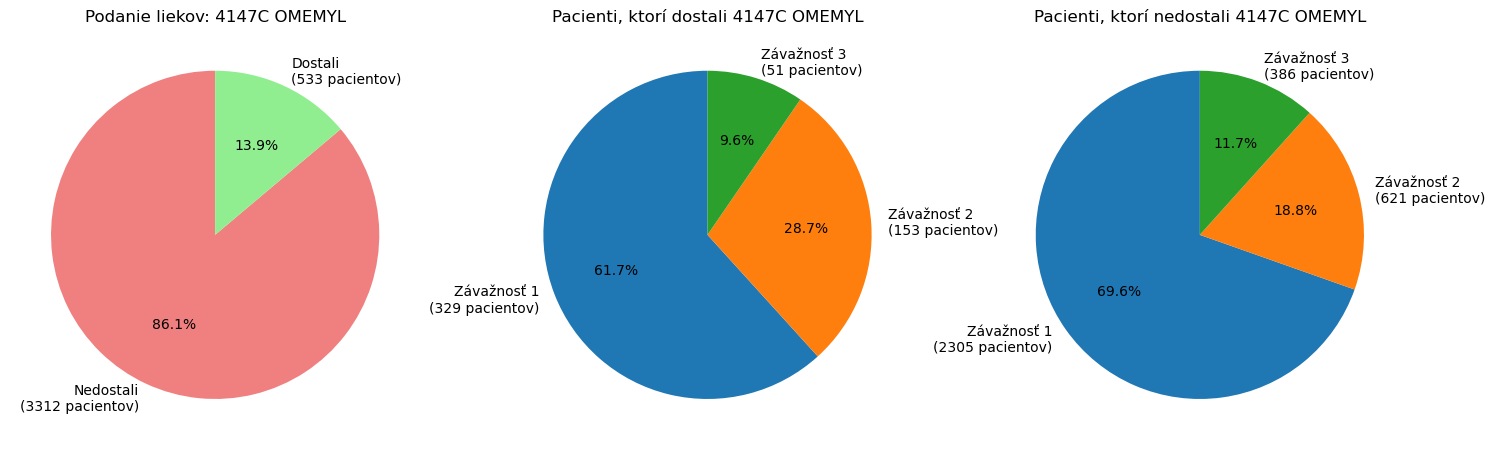

Chí-kvadrát: 28.512884309820585
p-hodnota: 6.434367181042395e-07
Cramerovo V: 0.08611373057144389


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '4147C OMEMYL'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '4147C OMEMYL'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

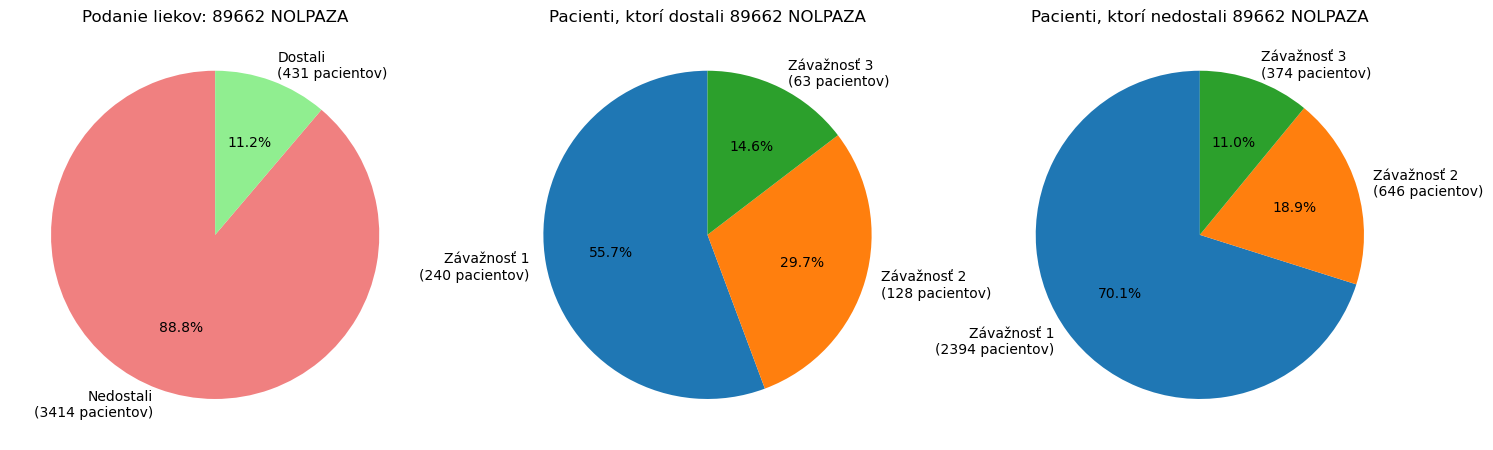

Chí-kvadrát: 38.2389039813551
p-hodnota: 4.971958596440992e-09
Cramerovo V: 0.09972511501483336


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '89662 NOLPAZA'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '89662 NOLPAZA'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

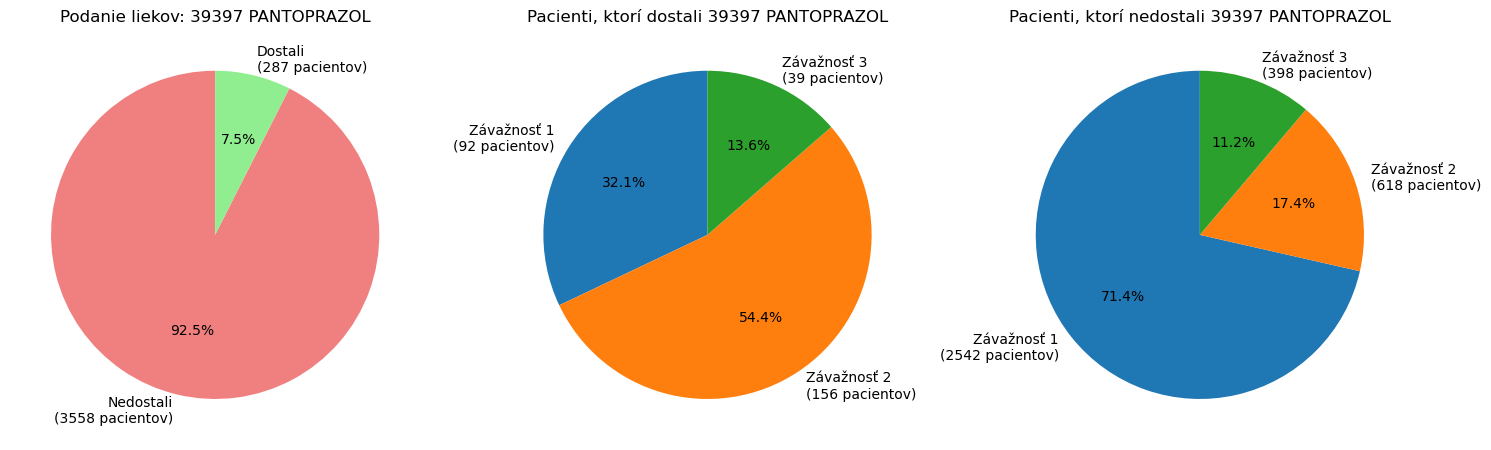

Chí-kvadrát: 241.97462643968854
p-hodnota: 2.856784549159102e-53
Cramerovo V: 0.25086307532015695


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '39397 PANTOPRAZOL'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '39397 PANTOPRAZOL'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

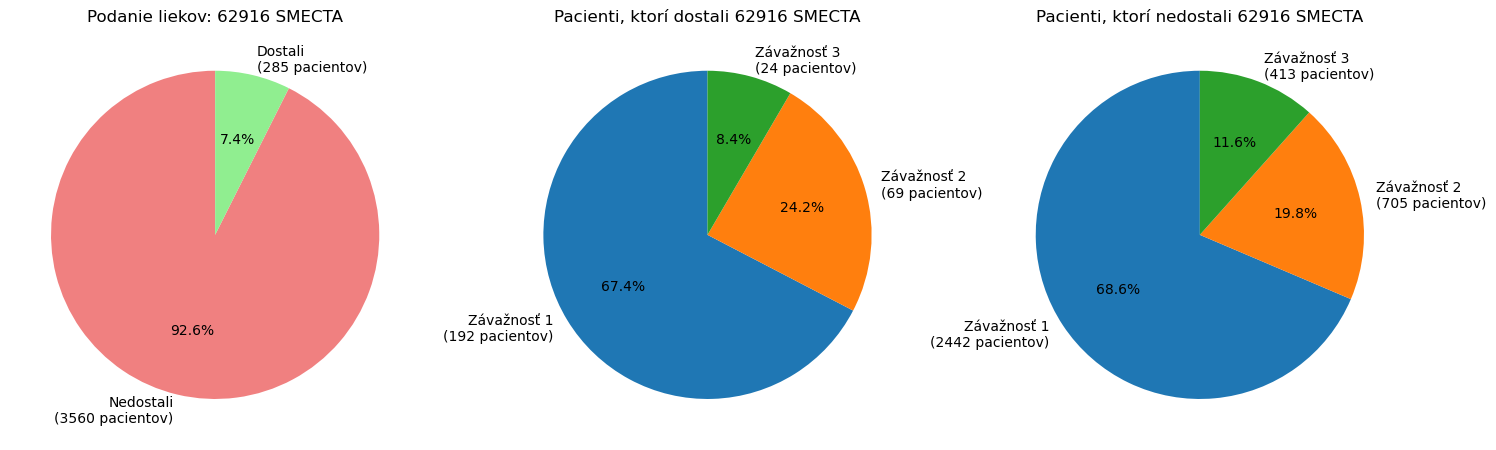

Chí-kvadrát: 4.952012105446615
p-hodnota: 0.08407836042993254
Cramerovo V: 0.035887456308189375


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '62916 SMECTA'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '62916 SMECTA'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

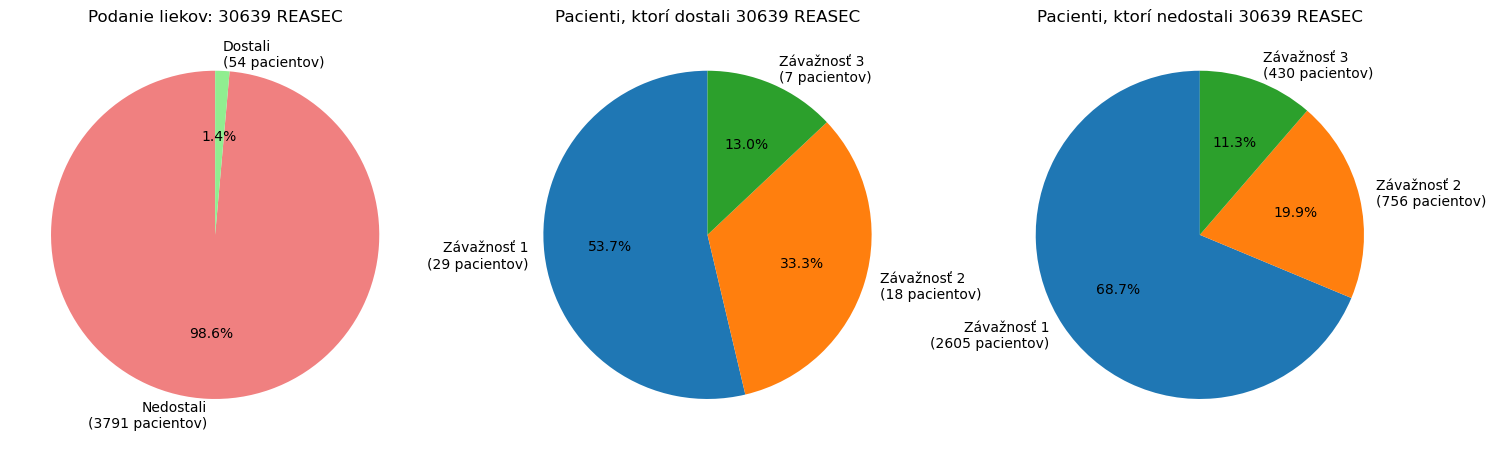

Chí-kvadrát: 6.61744164372129
p-hodnota: 0.036562914333329435
Cramerovo V: 0.04148555342176778


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '30639 REASEC'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '30639 REASEC'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

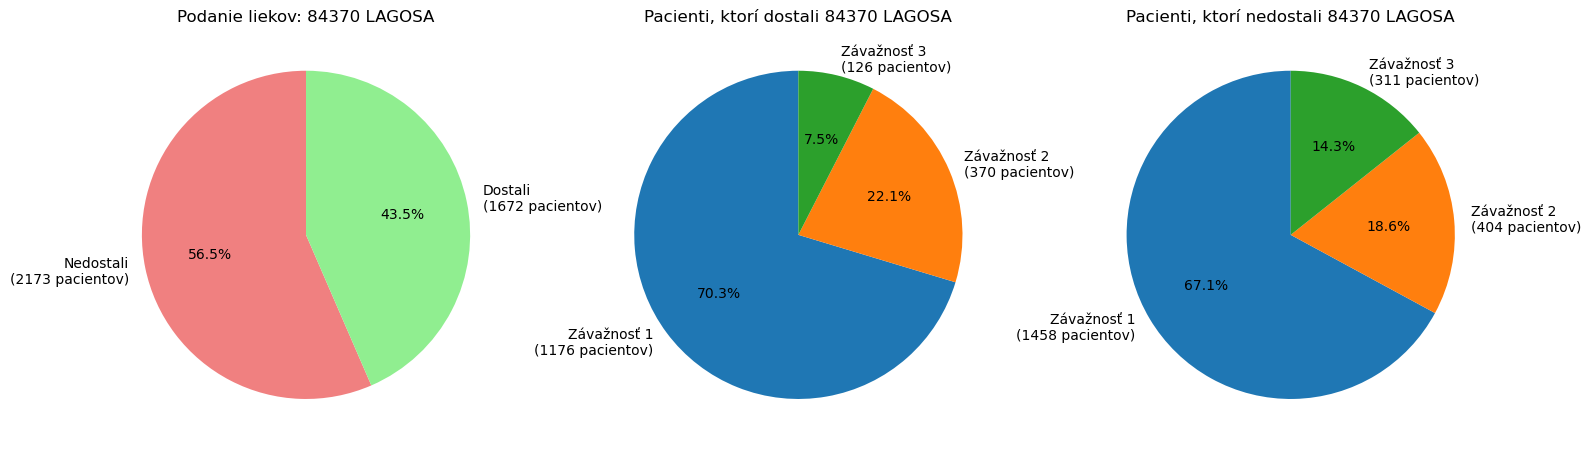

Chí-kvadrát: 45.49553434975509
p-hodnota: 1.3205967992452916e-10
Cramerovo V: 0.10877678358698874


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '84370 LAGOSA'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '84370 LAGOSA'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

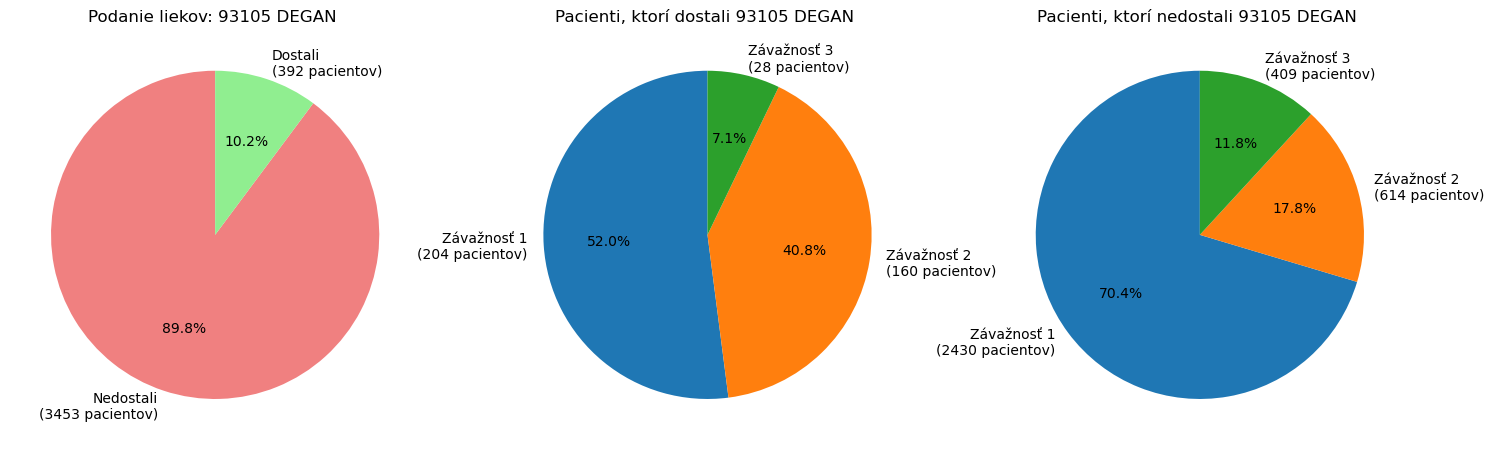

Chí-kvadrát: 116.9101229938894
p-hodnota: 4.1047749618425515e-26
Cramerovo V: 0.1743724568403009


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '93105 DEGAN '
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '93105 DEGAN '

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

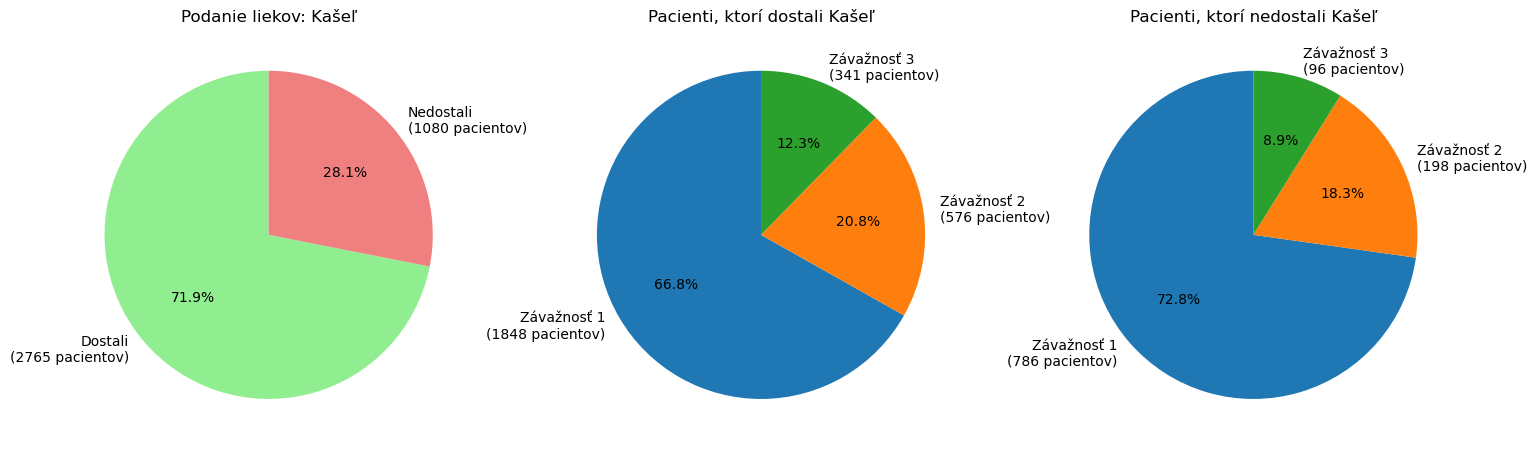

Chí-kvadrát: 14.516178680865137
p-hodnota: 0.0007044527199095393
Cramerovo V: 0.061443787796184555


In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '94918 AMBROBENE',
    '24859 PENTOXYPHILLINUM',
    '8893 ACC INJEKT',
    '24949 CODEIN ',
    '26846 OXANTIL'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = 'Kašeľ'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightgreen', 'lightcoral']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

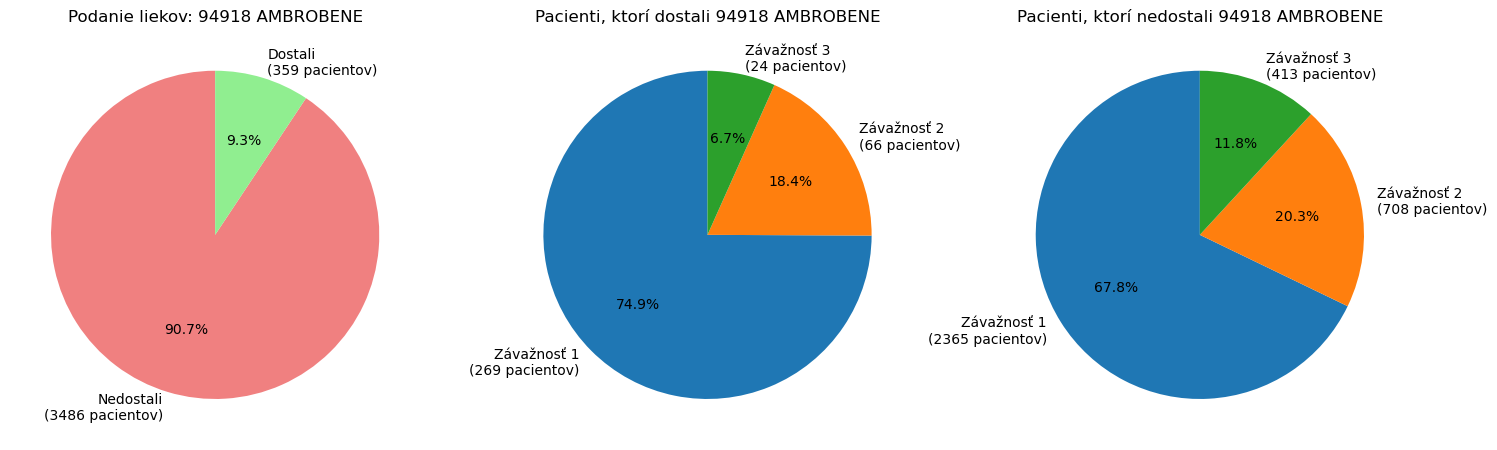

Chí-kvadrát: 10.617488234243071
p-hodnota: 0.004948137097769917
Cramerovo V: 0.052548790219273854


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '94918 AMBROBENE'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '94918 AMBROBENE'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

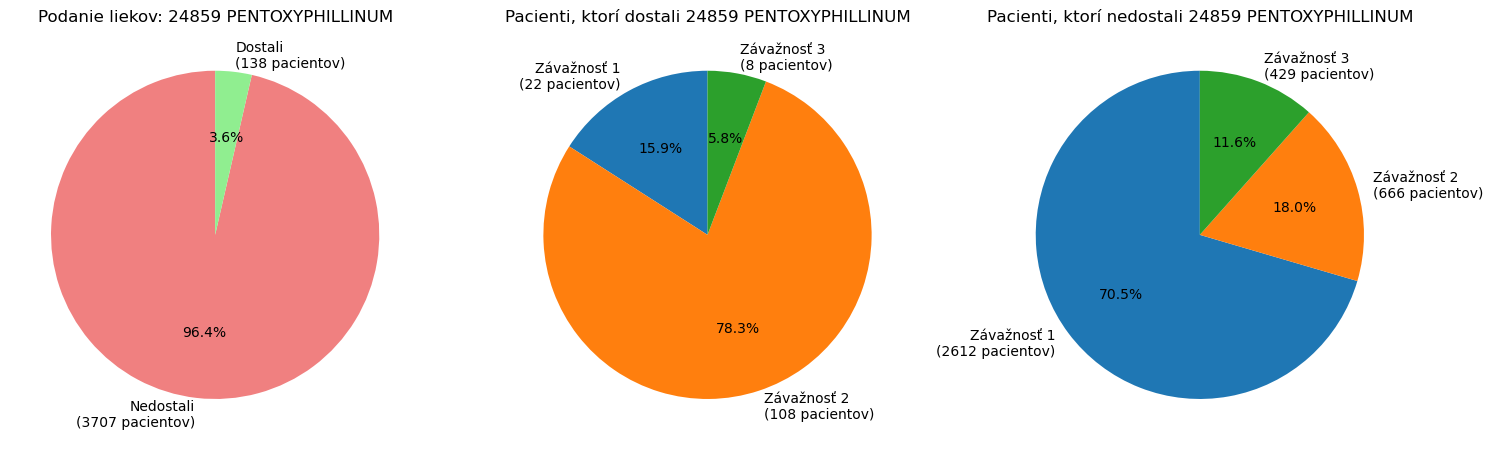

Chí-kvadrát: 301.91487190907645
p-hodnota: 2.754346427514302e-66
Cramerovo V: 0.28021674311735345


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '24859 PENTOXYPHILLINUM'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '24859 PENTOXYPHILLINUM'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

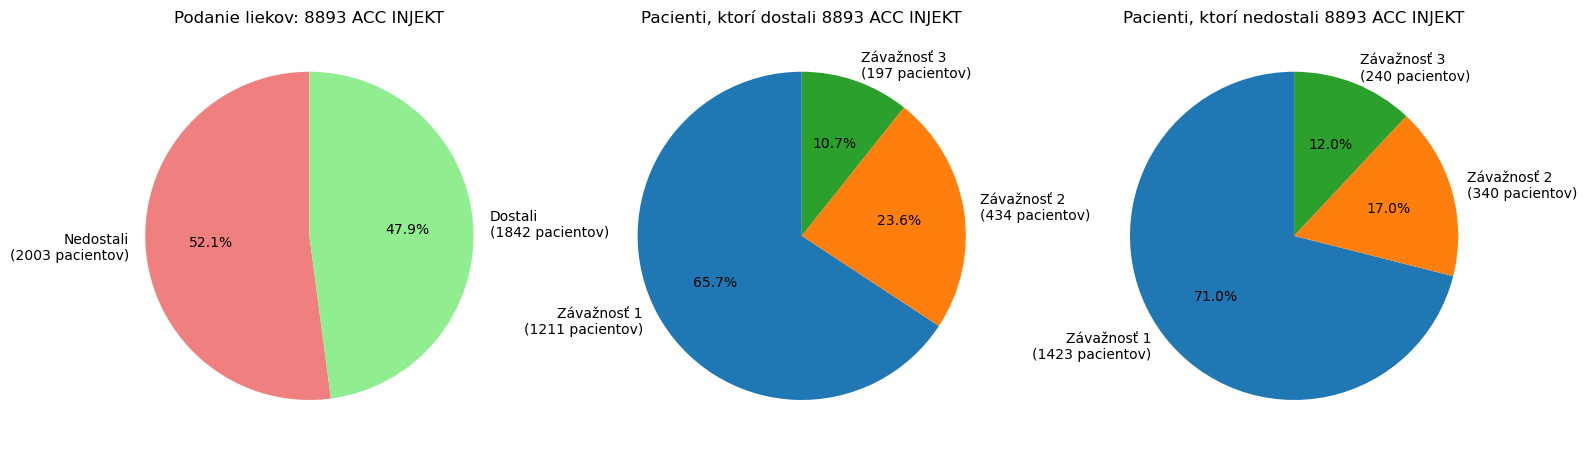

Chí-kvadrát: 26.01429268499104
p-hodnota: 2.244233899391033e-06
Cramerovo V: 0.08225415382729448


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '8893 ACC INJEKT'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '8893 ACC INJEKT'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

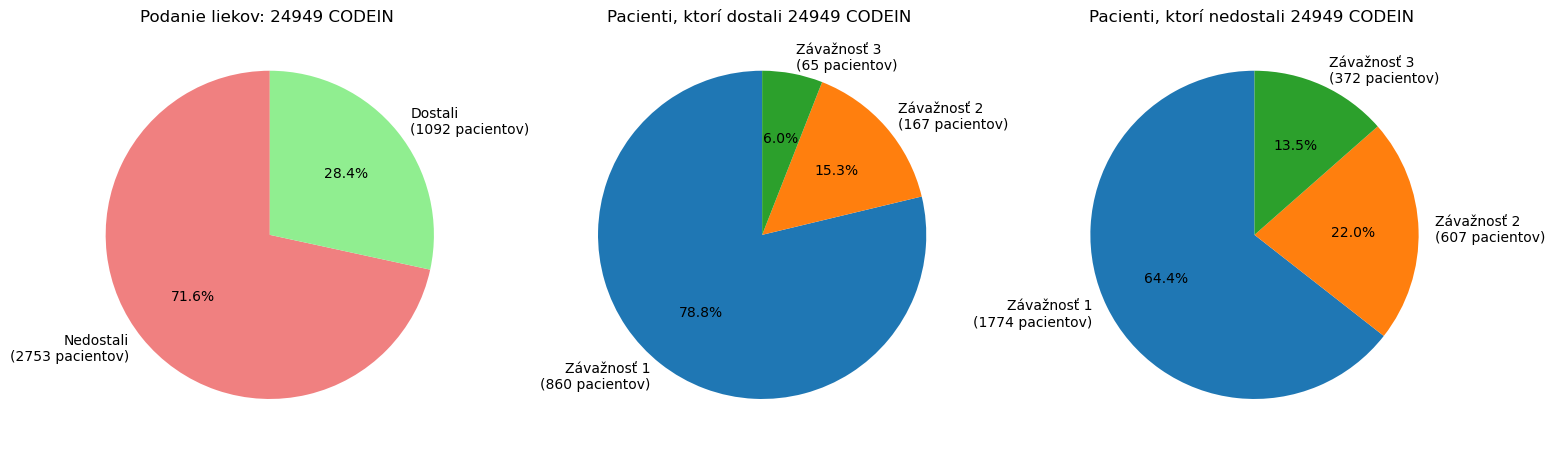

Chí-kvadrát: 80.43662273169126
p-hodnota: 3.4151462164385805e-18
Cramerovo V: 0.14463677903491423


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '24949 CODEIN '
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '24949 CODEIN '

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

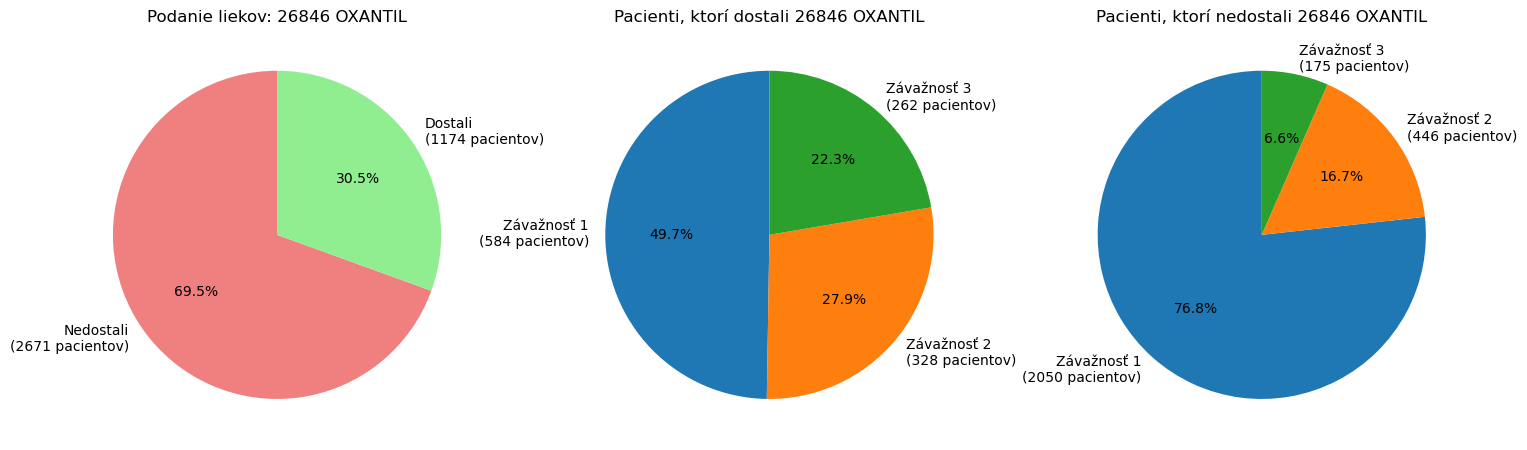

Chí-kvadrát: 316.3556487923916
p-hodnota: 2.0148545726125172e-69
Cramerovo V: 0.28683994113716327


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    '26846 OXANTIL'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = '26846 OXANTIL'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

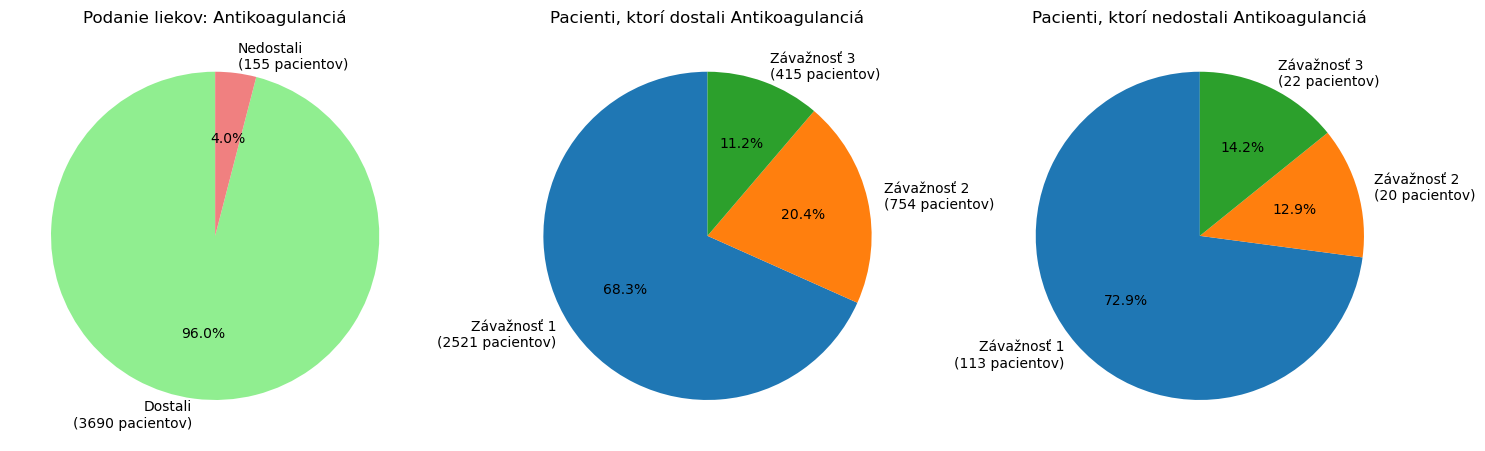

Chí-kvadrát: 5.7831502896705596
p-hodnota: 0.055488740935588296
Cramerovo V: 0.03878234516378898


In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    'FRAXIPARIN',
    'CLEXANE',
    'FRAGMIN',
    'ASPIRIN',
    'ANOPYRIN' 
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = 'Antikoagulanciá'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightgreen', 'lightcoral']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

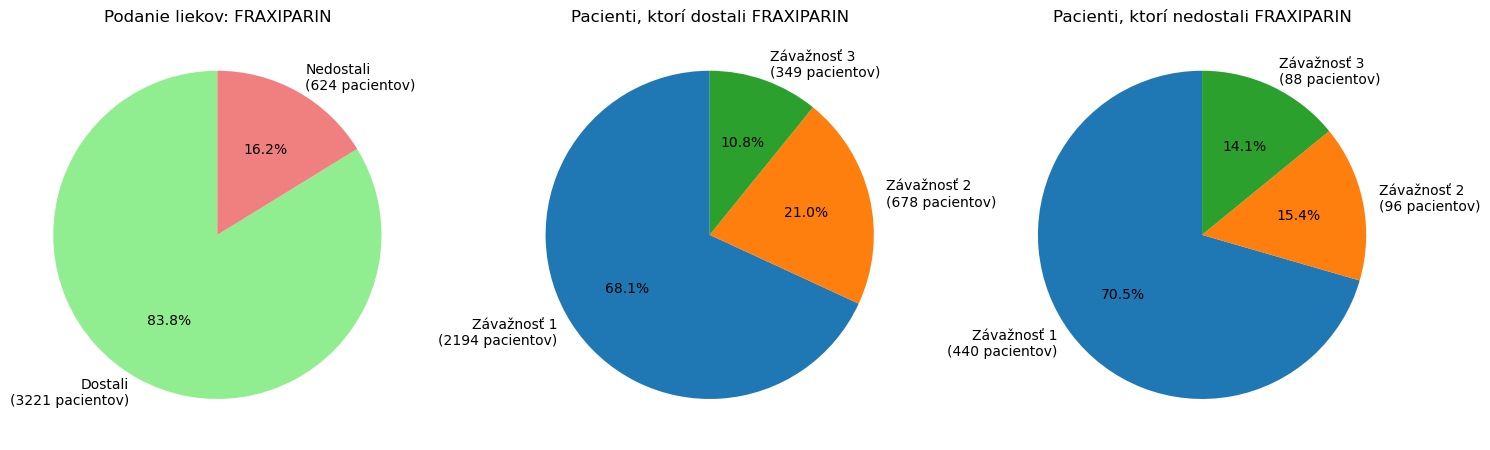

Chí-kvadrát: 13.681685386823041
p-hodnota: 0.0010692020104058086
Cramerovo V: 0.05965153554001502


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    'FRAXIPARIN'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = 'FRAXIPARIN'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightgreen', 'lightcoral']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

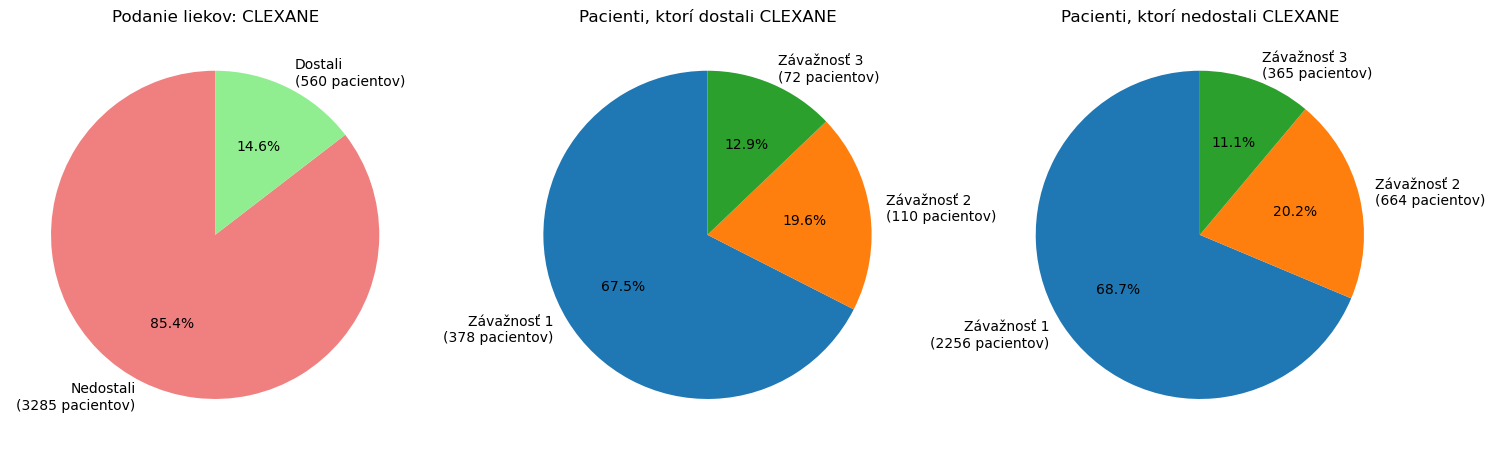

Chí-kvadrát: 1.4571915807642468
p-hodnota: 0.4825861666666875
Cramerovo V: 0.019467498710684927


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    'CLEXANE'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = 'CLEXANE'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

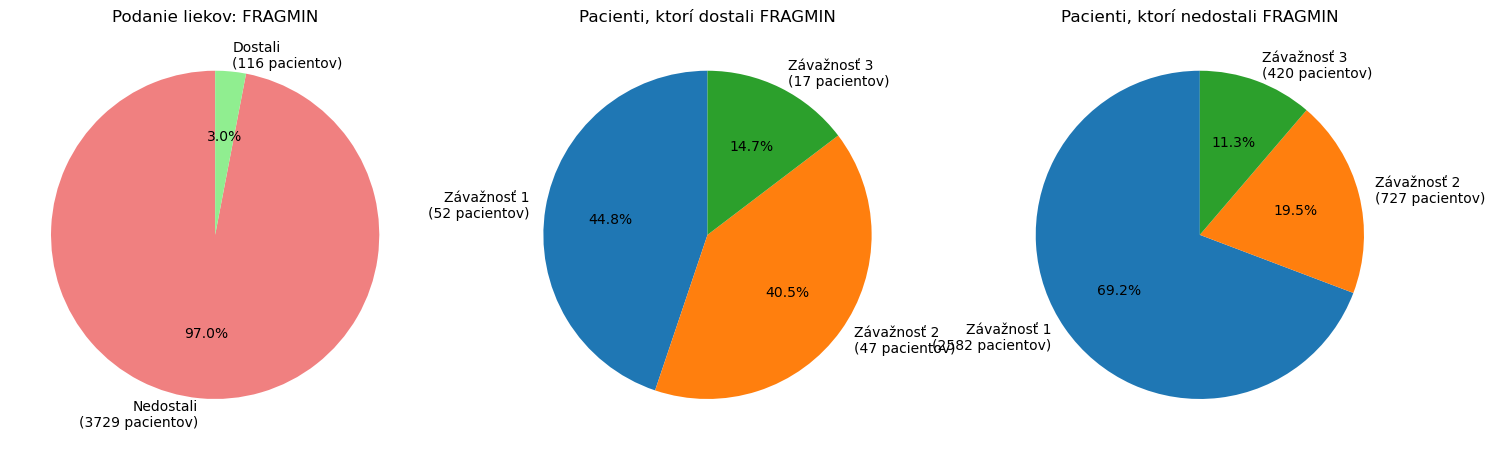

Chí-kvadrát: 35.62330816756162
p-hodnota: 1.8386409051204384e-08
Cramerovo V: 0.0962540366708776


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    'FRAGMIN'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = 'FRAGMIN'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

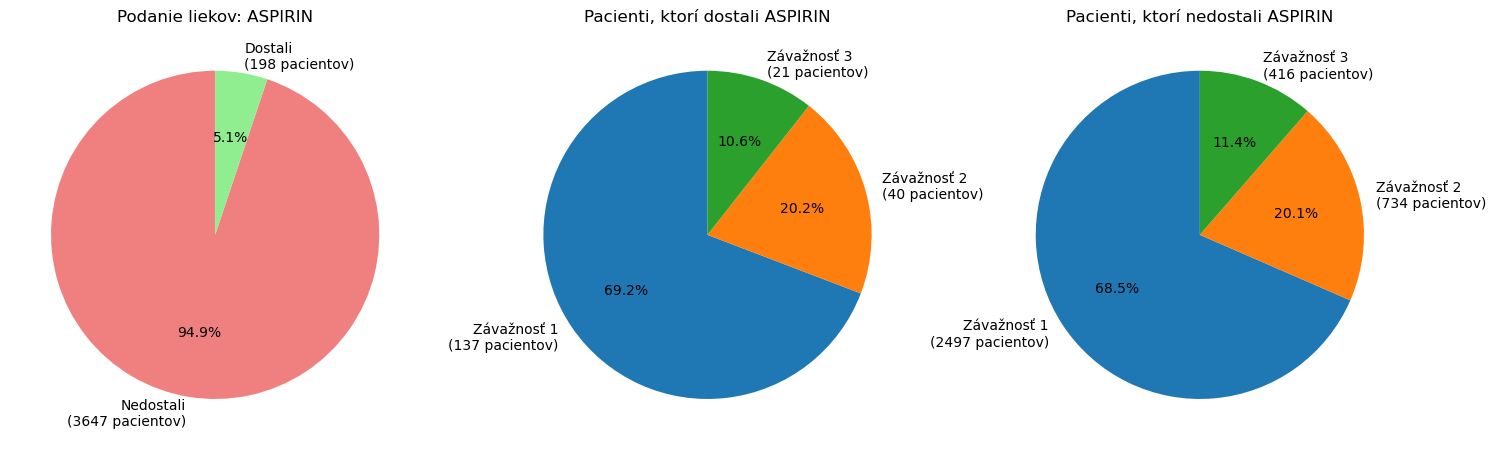

Chí-kvadrát: 0.12084145268341634
p-hodnota: 0.9413683917767734
Cramerovo V: 0.00560608652801008


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    'ASPIRIN'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = 'ASPIRIN'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)

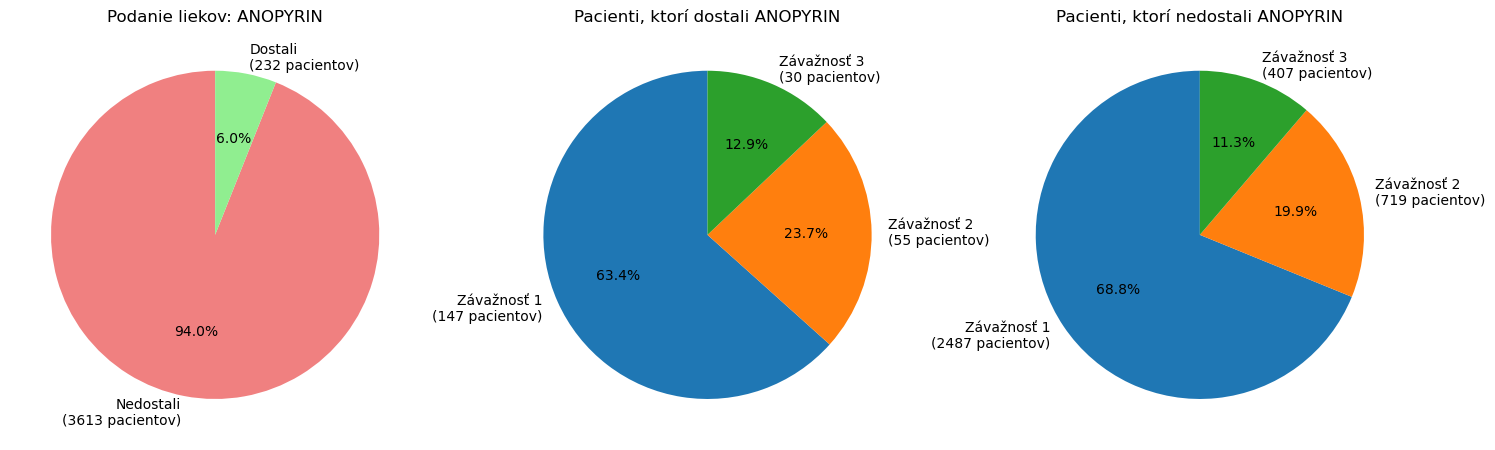

Chí-kvadrát: 3.054781369102439
p-hodnota: 0.2171014149639934
Cramerovo V: 0.0281865482174877


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


lieky = [
    'ANOPYRIN'
]
df['lieky'] = df[lieky].any(axis=1).astype(int)
df['status'] = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})


drug = 'ANOPYRIN'

statuses = ['Dostali', 'Nedostali']
titles = [f'Pacienti, ktorí dostali {drug}', f'Pacienti, ktorí nedostali {drug}']
total_counts = df['status'].value_counts()

colors_total = ['lightcoral', 'lightgreen']
labels_total = [f"{label}\n({count} pacientov)" for label, count in zip(total_counts.index, total_counts.values)]
axes[0].pie(total_counts, labels=labels_total, autopct='%1.1f%%', startangle=90, colors=colors_total)
axes[0].set_title(f'Podanie liekov: {drug}')

for i, stat in enumerate(statuses):
    subset = df[df['status'] == stat]
    severity_counts = subset['Závažnosť priebehu ochorenia'].value_counts().sort_index()
    
    
    labels = [f"Závažnosť {fmt_label(sev)}\n({cnt} pacientov)" for sev, cnt in zip(severity_counts.index, severity_counts.values)]
    
    axes[i+1].pie(severity_counts, labels=labels, autopct='%1.1f%%', startangle=90)
    axes[i+1].set_title(titles[i])

plt.show()

df['lieky'] = df[lieky].any(axis=1).astype(int)
status = df['lieky'].map({1: 'Dostali', 0: 'Nedostali'})

table = pd.crosstab(df['Závažnosť priebehu ochorenia'], status)
chi2, p, dof, expected = chi2_contingency(table.values)

print("Chí-kvadrát:", chi2)
print("p-hodnota:", p)

cramer_v = association(table, method='cramer')
print("Cramerovo V:", cramer_v)